<a href="https://colab.research.google.com/github/Ekazadex/TekkomJadex/blob/main/fashion_mnist_ann_UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas UTS: Regularization & Hyperparameter Tuning
## Artificial Neural Network (ANN) dengan TensorFlow — Fashion MNIST

**Mata Kuliah:** Artificial Intelligence  
**Topik:** Regularization, Hyperparameter Tuning, dan Optimization  
**Dataset:** Fashion MNIST (Zalando Research)  
**Framework:** TensorFlow / Keras

---

## Pendahuluan

Notebook ini mengimplementasikan dan menganalisis berbagai teknik untuk membangun Artificial Neural Network (ANN) yang optimal pada dataset **Fashion MNIST**. Dataset ini terdiri dari 70.000 gambar grayscale berukuran 28×28 piksel dari 10 kategori pakaian (T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot).

Eksperimen yang dilakukan mencakup:
1. Preprocessing data & pembagian dataset
2. Model baseline sebagai acuan
3. Coarse-to-fine hyperparameter search (layers, neurons, activation, learning rate, batch size, epoch)
4. Regularization: Dropout, L2, Early Stopping
5. Batch Normalization
6. Weight Initialization
7. Perbandingan Optimizer (SGD, SGD+Momentum, Adam)
8. Analisis pengaruh Batch Size
9. Evaluasi model terbaik

---

## 0. Import Library & Konfigurasi Global

In [ ]:
# ─── Standard Libraries ───
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import time
import itertools
warnings.filterwarnings('ignore')

# ─── TensorFlow / Keras ───
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, initializers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ─── Reproducibility ───
# Menetapkan random seed agar hasil dapat direproduksi
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Display settings ───
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Nama kelas Fashion MNIST
CLASS_NAMES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')
print(f'NumPy version      : {np.__version__}')
print(f'Random seed        : {SEED}')

TensorFlow version : 2.19.0
Keras version      : 3.13.2
NumPy version      : 2.0.2
Random seed        : 42


---
## 1. Preprocessing Data

### 1.1 Load Dataset

Fashion MNIST sudah tersedia langsung di Keras. Dataset ini terdiri dari:
- **60.000** gambar untuk training
- **10.000** gambar untuk testing

Setiap gambar berukuran **28 × 28 piksel** dengan nilai piksel dalam rentang [0, 255].

In [ ]:
# Load dataset Fashion MNIST dari Keras
(X_train_full, y_train_full), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

print('=== Informasi Dataset Fashion MNIST ===')
print(f'Training set (raw) : {X_train_full.shape}  |  Label: {y_train_full.shape}')
print(f'Test set (raw)     : {X_test_raw.shape}    |  Label: {y_test_raw.shape}')
print(f'Tipe data piksel   : {X_train_full.dtype}')
print(f'Nilai piksel       : min={X_train_full.min()}, max={X_train_full.max()}')
print(f'Jumlah kelas       : {len(CLASS_NAMES)}')
print(f'Nama kelas         : {CLASS_NAMES}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
=== Informasi Dataset Fashion MNIST ===
Training set (raw) : (60000, 28, 28)  |  Label: (60000,)
Test set (raw)     : (10000, 28, 28)    |  Label: (10000,)
Tipe data piksel   : uint8
Nilai piksel       : min=0, max=255
Jumlah kelas       : 10
Nama kelas         : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


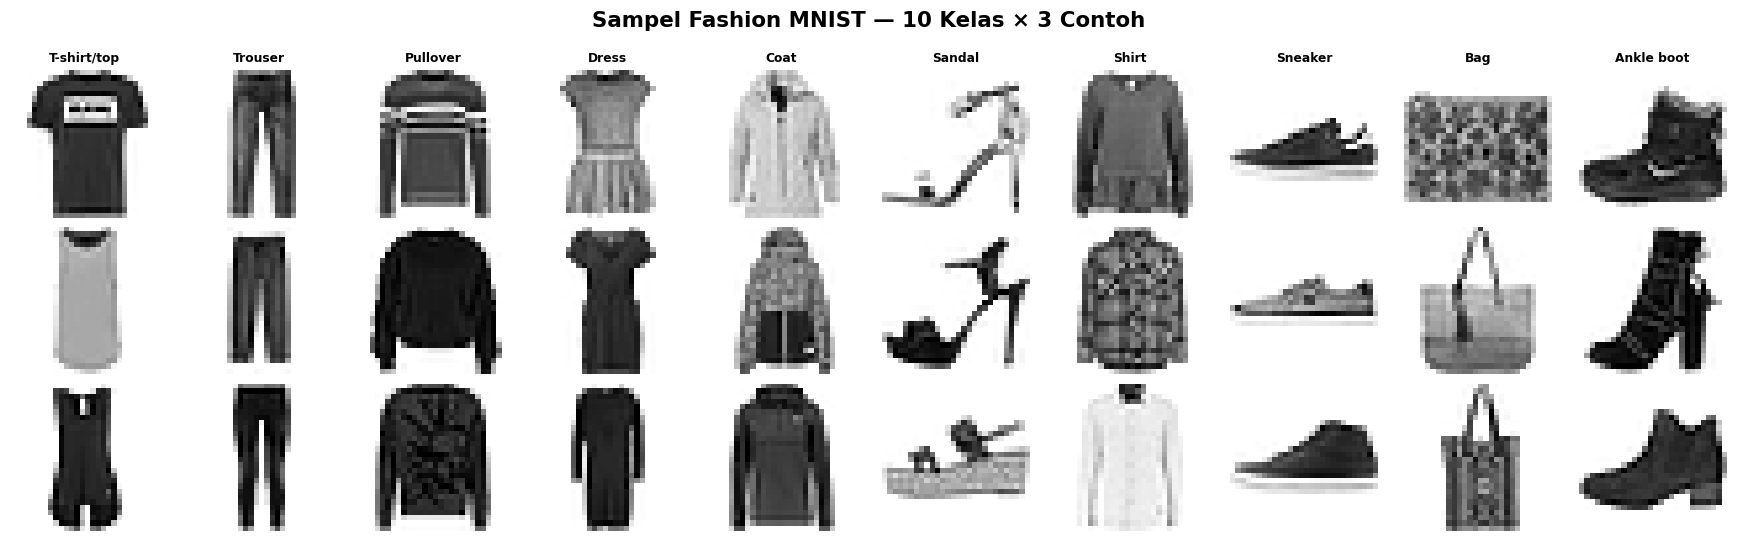

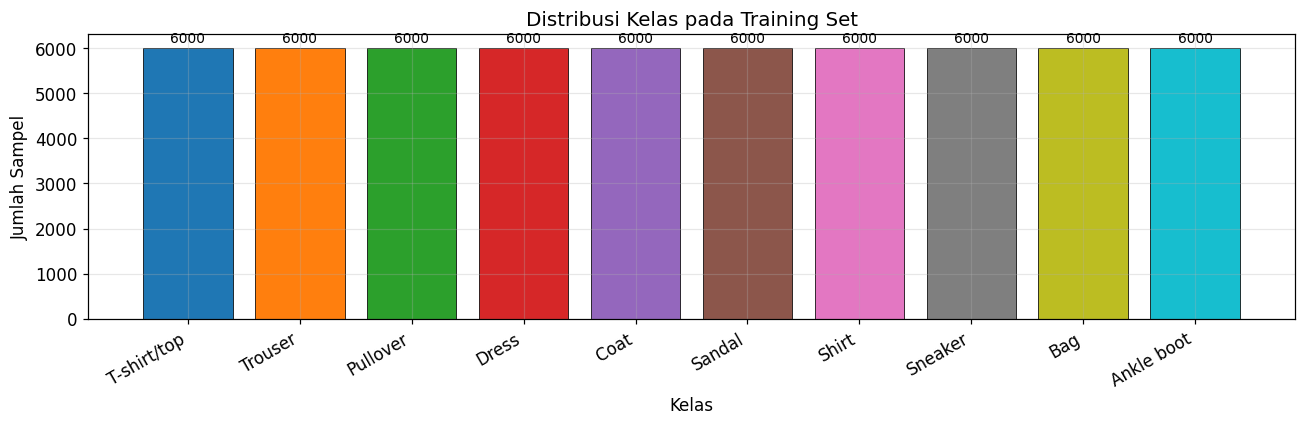

Distribusi kelas seimbang (6.000 per kelas) — tidak perlu oversampling.


In [ ]:
# Visualisasi beberapa sampel dari dataset
fig, axes = plt.subplots(3, 10, figsize=(16, 5))
fig.suptitle('Sampel Fashion MNIST — 10 Kelas × 3 Contoh', fontsize=14, fontweight='bold')

for class_idx in range(10):
    # Ambil 3 gambar pertama dari setiap kelas
    class_images = X_train_full[y_train_full == class_idx][:3]
    for row, img in enumerate(class_images):
        ax = axes[row, class_idx]
        ax.imshow(img, cmap='gray_r')
        ax.axis('off')
        if row == 0:
            ax.set_title(CLASS_NAMES[class_idx], fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Distribusi kelas
fig, ax = plt.subplots(figsize=(12, 4))
unique, counts = np.unique(y_train_full, return_counts=True)
bars = ax.bar(CLASS_NAMES, counts, color=plt.cm.tab10.colors, edgecolor='black', linewidth=0.5)
ax.set_title('Distribusi Kelas pada Training Set')
ax.set_ylabel('Jumlah Sampel')
ax.set_xlabel('Kelas')
plt.xticks(rotation=30, ha='right')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print('Distribusi kelas seimbang (6.000 per kelas) — tidak perlu oversampling.')

### 1.2 Normalisasi & Pembagian Dataset

**Normalisasi** adalah langkah penting sebelum melatih neural network. Nilai piksel mentah berkisar [0, 255], yang bila tidak dinormalisasi akan menyebabkan:
- Loss surface berbentuk elongated (seperti pisang) yang memperlambat konvergensi gradient descent
- Bobot yang diperbarui secara tidak seimbang antar fitur

Kita akan membagi 60.000 data training menjadi:
- **Training set** (~85%): 51.000 sampel — digunakan untuk mengoptimasi bobot model
- **Validation set / Dev set** (~15%): 9.000 sampel — digunakan untuk memilih hyperparameter & mendeteksi overfitting
- **Test set**: 10.000 sampel — hanya digunakan **sekali** di akhir untuk evaluasi final

Pemisahan ini sesuai dengan prinsip **train/dev/test split** dari materi kuliah.

In [ ]:
# ─── Normalisasi ───
# Membagi dengan 255.0 sehingga semua piksel berada di rentang [0, 1]
# Menggunakan float32 untuk efisiensi memori GPU
X_train_full_norm = X_train_full.astype('float32') / 255.0
X_test_norm       = X_test_raw.astype('float32') / 255.0

# ─── Flatten 28×28 → 784 (untuk Dense/FC layers) ───
X_train_full_flat = X_train_full_norm.reshape(-1, 28*28)   # shape: (60000, 784)
X_test_flat       = X_test_norm.reshape(-1, 28*28)         # shape: (10000, 784)

# ─── Train / Validation Split ───
VAL_SIZE = 9000
X_val   = X_train_full_flat[:VAL_SIZE]   # 9.000 sampel pertama → validation
y_val   = y_train_full[:VAL_SIZE]
X_train = X_train_full_flat[VAL_SIZE:]   # Sisanya (51.000) → training
y_train = y_train_full[VAL_SIZE:]
X_test  = X_test_flat
y_test  = y_test_raw

print('=== Hasil Pembagian Dataset ===')
print(f'Training set   : {X_train.shape}  |  Label: {y_train.shape}  ({len(X_train)/60000*100:.1f}%)')
print(f'Validation set : {X_val.shape}   |  Label: {y_val.shape}   ({len(X_val)/60000*100:.1f}%)')
print(f'Test set       : {X_test.shape}  |  Label: {y_test.shape}  (fixed 10k)')
print(f'\nNilai piksel setelah normalisasi: min={X_train.min():.3f}, max={X_train.max():.3f}')
print('\n[CATATAN] Normalisasi yang sama (pembagian 255) diterapkan ke semua set.')
print('Kita TIDAK menghitung mean/std dari val/test set secara terpisah — menghindari data leakage.')

=== Hasil Pembagian Dataset ===
Training set   : (51000, 784)  |  Label: (51000,)  (85.0%)
Validation set : (9000, 784)   |  Label: (9000,)   (15.0%)
Test set       : (10000, 784)  |  Label: (10000,)  (fixed 10k)

Nilai piksel setelah normalisasi: min=0.000, max=1.000

[CATATAN] Normalisasi yang sama (pembagian 255) diterapkan ke semua set.
Kita TIDAK menghitung mean/std dari val/test set secara terpisah — menghindari data leakage.


---
## 2. Model Baseline

Model baseline adalah model sederhana yang dijadikan **acuan awal** sebelum melakukan optimasi apapun. Konsepnya selaras dengan *basic recipe for machine learning* dari Andrew Ng: pertama pahami apakah model mengalami **high bias** (underfitting) atau **high variance** (overfitting), lalu ambil tindakan yang tepat.

Baseline kita: ANN dengan 2 hidden layer (128 → 64 neuron), aktivasi ReLU, optimizer Adam default.

In [ ]:
def build_model(hidden_layers=[128, 64],
                activation='relu',
                learning_rate=0.001,
                optimizer_name='adam',
                regularizer=None,
                dropout_rate=0.0,
                use_batch_norm=False,
                kernel_initializer='glorot_uniform',
                input_dim=784,
                num_classes=10):
    """
    Fungsi generik untuk membangun model ANN fully-connected.

    Parameter:
    - hidden_layers    : list berisi jumlah neuron tiap hidden layer
    - activation       : fungsi aktivasi hidden layer ('relu', 'tanh', 'sigmoid', 'elu')
    - learning_rate    : ukuran langkah gradient descent
    - optimizer_name   : 'adam', 'sgd', 'sgd_momentum', 'rmsprop'
    - regularizer      : objek keras.regularizers (L1/L2) atau None
    - dropout_rate     : laju dropout (0.0 = tidak ada dropout)
    - use_batch_norm   : apakah menggunakan Batch Normalization
    - kernel_initializer: inisialisasi bobot ('glorot_uniform', 'he_normal', dll.)
    """
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))

    # ─── Hidden Layers ───
    for units in hidden_layers:
        model.add(layers.Dense(
            units,
            activation=None if use_batch_norm else activation,
            kernel_regularizer=regularizer,
            kernel_initializer=kernel_initializer
        ))
        # Batch Norm diterapkan SEBELUM aktivasi (standar modern)
        if use_batch_norm:
            model.add(layers.BatchNormalization())
            model.add(layers.Activation(activation))
        # Dropout diterapkan SETELAH aktivasi
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, seed=SEED))

    # ─── Output Layer ───
    # Softmax untuk klasifikasi 10 kelas
    model.add(layers.Dense(num_classes, activation='softmax',
                           kernel_initializer=kernel_initializer))

    # ─── Optimizer ───
    if optimizer_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'sgd_momentum':
        # SGD dengan momentum β = 0.9 (nilai default yang direkomendasikan Andrew Ng)
        opt = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer_name == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def train_and_evaluate(model, X_tr, y_tr, X_v, y_v,
                       epochs=30, batch_size=64,
                       callbacks=None, verbose=0):
    """Wrapper untuk training & evaluasi dengan pencatatan waktu."""
    t0 = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks or [],
        verbose=verbose
    )
    elapsed = time.time() - t0
    val_acc  = max(history.history['val_accuracy'])
    val_loss = min(history.history['val_loss'])
    return history, val_acc, val_loss, elapsed


def plot_history(history, title='Training History', ax1=None, ax2=None):
    """Memplot kurva loss dan accuracy training vs validation."""
    standalone = ax1 is None
    if standalone:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle(title, fontweight='bold')

    epochs_ran = range(1, len(history.history['loss'])+1)

    ax1.plot(epochs_ran, history.history['loss'], label='Train Loss', color='steelblue')
    ax1.plot(epochs_ran, history.history['val_loss'], label='Val Loss',
             color='tomato', linestyle='--')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend()

    ax2.plot(epochs_ran, history.history['accuracy'], label='Train Acc', color='steelblue')
    ax2.plot(epochs_ran, history.history['val_accuracy'], label='Val Acc',
             color='tomato', linestyle='--')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy'); ax2.legend()

    if standalone:
        plt.tight_layout()
        plt.show()

print('Fungsi helper berhasil didefinisikan.')

Fungsi helper berhasil didefinisikan.


In [ ]:
# ─── Bangun & Latih Model Baseline ───
print('=== MODEL BASELINE ===')
print('Konfigurasi: 2 hidden layers [128, 64], ReLU, Adam(lr=0.001), batch=64, epoch=30')
print('-' * 60)

baseline_model = build_model(
    hidden_layers=[128, 64],
    activation='relu',
    learning_rate=0.001,
    optimizer_name='adam'
)

# Tampilkan arsitektur
baseline_model.summary()
print()

# Training
baseline_history, baseline_val_acc, baseline_val_loss, baseline_time = train_and_evaluate(
    baseline_model, X_train, y_train, X_val, y_val,
    epochs=30, batch_size=64, verbose=1
)

print(f'\n=== Hasil Baseline ===')
print(f'Best Val Accuracy  : {baseline_val_acc:.4f} ({baseline_val_acc*100:.2f}%)')
print(f'Best Val Loss      : {baseline_val_loss:.4f}')
print(f'Train Accuracy     : {max(baseline_history.history["accuracy"]):.4f}')
print(f'Training Time      : {baseline_time:.1f} detik')

=== MODEL BASELINE ===
Konfigurasi: 2 hidden layers [128, 64], ReLU, Adam(lr=0.001), batch=64, epoch=30
------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 1/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8139 - loss: 0.5330 - val_accuracy: 0.8491 - val_loss: 0.4193
Epoch 2/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8614 - loss: 0.3824 - val_accuracy: 0.8650 - val_loss: 0.3711
Epoch 3/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8745 - loss: 0.3427 - val_accuracy: 0.8706 - val_loss: 0.3533
Epoch 4/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8829 - loss: 0.3163 - val_accuracy: 0.8738 - val_loss: 0.3473
Epoch 5/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8902 - loss: 0.2971 - val_accuracy: 0.8730 - val_loss: 0.3447
Epoch 6/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8950 - loss: 0.2823 - val_accuracy: 0.8757 - val_loss: 0.3381
Epoch 7/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8998 - loss: 0.2681 - val_accuracy: 0.8783 - val_loss: 0.3369
Epoch 8/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9042 - loss: 0.2561 - val_accuracy: 0

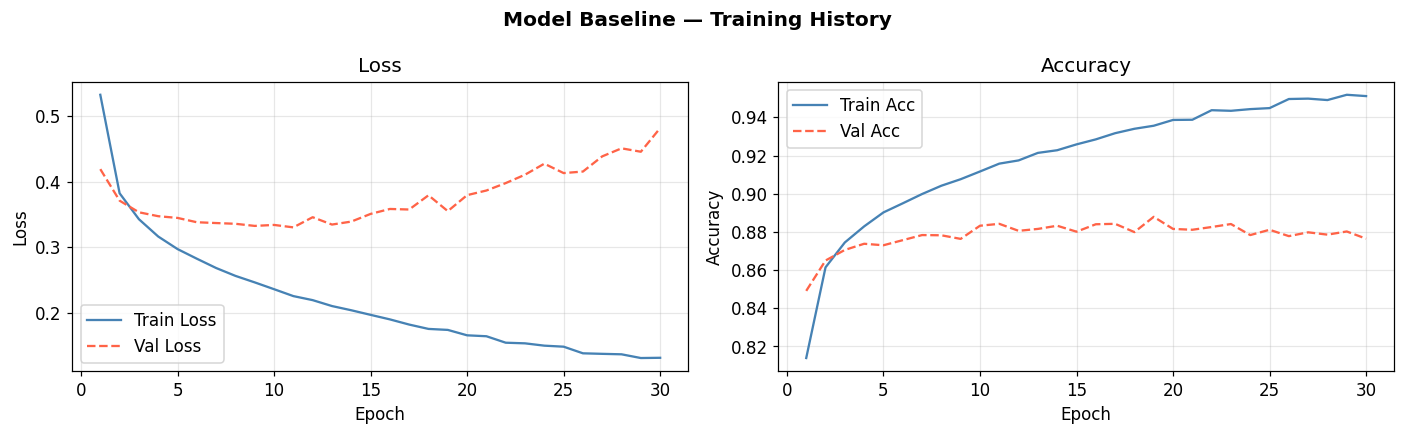

=== Diagnosis Bias-Variance Baseline ===
Train Accuracy (epoch terakhir) : 0.9511
Val Accuracy   (epoch terakhir) : 0.8764
Generalization Gap             : 0.0747
→ Indikasi HIGH VARIANCE (overfitting): selisih train-val besar.
  Solusi: regularization, lebih banyak data, atau arsitektur lebih sederhana.


In [ ]:
# Plot kurva baseline
plot_history(baseline_history, title='Model Baseline — Training History')

# Diagnosis Bias-Variance pada Baseline
final_train_acc = baseline_history.history['accuracy'][-1]
final_val_acc   = baseline_history.history['val_accuracy'][-1]
gap = final_train_acc - final_val_acc

print('=== Diagnosis Bias-Variance Baseline ===')
print(f'Train Accuracy (epoch terakhir) : {final_train_acc:.4f}')
print(f'Val Accuracy   (epoch terakhir) : {final_val_acc:.4f}')
print(f'Generalization Gap             : {gap:.4f}')
if gap > 0.05:
    print('→ Indikasi HIGH VARIANCE (overfitting): selisih train-val besar.')
    print('  Solusi: regularization, lebih banyak data, atau arsitektur lebih sederhana.')
elif final_train_acc < 0.85:
    print('→ Indikasi HIGH BIAS (underfitting): akurasi training masih rendah.')
    print('  Solusi: model lebih besar, lebih banyak epoch, atau learning rate disesuaikan.')
else:
    print('→ Model baseline cukup baik sebagai titik awal.')

---
## 3. Eksplorasi Hyperparameter: Coarse-to-Fine Search

Pendekatan **coarse-to-fine search** yang diajarkan Andrew Ng bekerja dalam dua tahap:

1. **Coarse Search**: Menjelajahi ruang hyperparameter secara luas dengan *random sampling* pada rentang nilai yang besar. Tujuannya adalah mengidentifikasi region yang menjanjikan.
2. **Fine Search**: Memperbesar pencarian (zoom in) ke region terbaik, menyampling lebih rapat untuk menemukan nilai optimal.

Keuntungan *random search* dibanding *grid search*: dengan 25 eksperimen, grid search hanya menjelajahi 5 nilai berbeda per hyperparameter, sementara random search menjelajahi 25 nilai berbeda per hyperparameter.

### 3.1 Variasi Jumlah Layer & Neuron

In [ ]:
# ─── Coarse Search: Arsitektur (Layer & Neuron) ───
print('=== COARSE SEARCH: Jumlah Layer & Neuron ===')
print('Mengeksplorasi berbagai kedalaman dan lebar jaringan...')
print('-' * 60)

arch_configs = [
    [64],                      # 1 hidden layer, kecil
    [256],                     # 1 hidden layer, besar
    [128, 64],                 # 2 hidden layers (baseline)
    [256, 128],                # 2 hidden layers, lebih besar
    [512, 256, 128],           # 3 hidden layers
    [256, 128, 64],            # 3 hidden layers, sedang
    [512, 256, 128, 64],       # 4 hidden layers
    [128, 128, 64, 32],        # 4 hidden layers, lebih kecil
]

arch_results = []

for arch in arch_configs:
    model = build_model(hidden_layers=arch, learning_rate=0.001)
    _, val_acc, val_loss, t = train_and_evaluate(
        model, X_train, y_train, X_val, y_val, epochs=20, batch_size=128
    )
    n_params = model.count_params()
    arch_results.append({
        'Arsitektur': str(arch),
        'Jumlah Layer': len(arch),
        'Total Params': n_params,
        'Val Accuracy': round(val_acc, 4),
        'Val Loss': round(val_loss, 4),
        'Waktu (s)': round(t, 1)
    })
    print(f'  Arch {str(arch):30s} → Val Acc: {val_acc:.4f} | Params: {n_params:,}')

arch_df = pd.DataFrame(arch_results).sort_values('Val Accuracy', ascending=False)
print('\n=== Rangkuman Coarse Search Arsitektur ===')
print(arch_df.to_string(index=False))

=== COARSE SEARCH: Jumlah Layer & Neuron ===
Mengeksplorasi berbagai kedalaman dan lebar jaringan...
------------------------------------------------------------
  Arch [64]                           → Val Acc: 0.8829 | Params: 50,890
  Arch [256]                          → Val Acc: 0.8952 | Params: 203,530
  Arch [128, 64]                      → Val Acc: 0.8882 | Params: 109,386
  Arch [256, 128]                     → Val Acc: 0.8887 | Params: 235,146
  Arch [512, 256, 128]                → Val Acc: 0.8872 | Params: 567,434
  Arch [256, 128, 64]                 → Val Acc: 0.8868 | Params: 242,762
  Arch [512, 256, 128, 64]            → Val Acc: 0.8908 | Params: 575,050
  Arch [128, 128, 64, 32]             → Val Acc: 0.8871 | Params: 127,658

=== Rangkuman Coarse Search Arsitektur ===
         Arsitektur  Jumlah Layer  Total Params  Val Accuracy  Val Loss  Waktu (s)
              [256]             1        203530        0.8952    0.3194       27.2
[512, 256, 128, 64]             4    

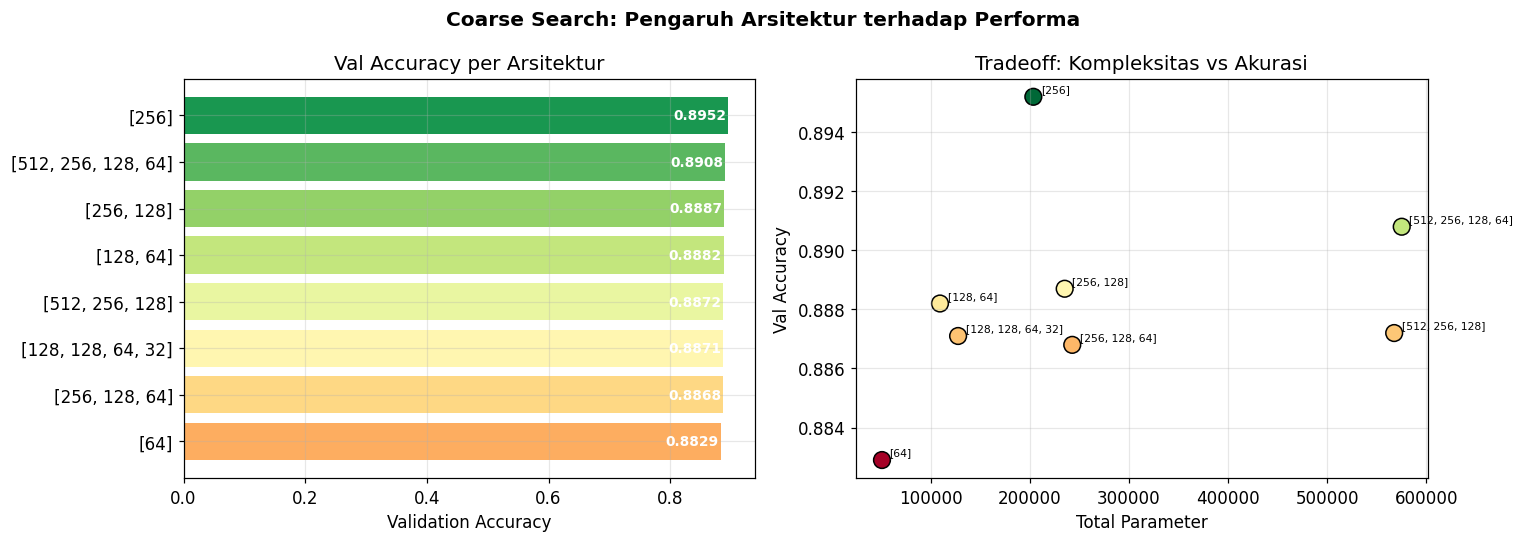


✓ Arsitektur terbaik (coarse): [256] → Val Acc: 0.8952


In [ ]:
# Visualisasi hasil coarse search arsitektur
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Coarse Search: Pengaruh Arsitektur terhadap Performa', fontweight='bold')

sorted_df = arch_df.sort_values('Val Accuracy', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(sorted_df)))

bars = axes[0].barh(sorted_df['Arsitektur'], sorted_df['Val Accuracy'], color=colors)
axes[0].set_xlabel('Validation Accuracy')
axes[0].set_title('Val Accuracy per Arsitektur')
for bar, acc in zip(bars, sorted_df['Val Accuracy']):
    axes[0].text(bar.get_width() - 0.003, bar.get_y() + bar.get_height()/2,
                 f'{acc:.4f}', va='center', ha='right', fontsize=9, color='white', fontweight='bold')

axes[1].scatter(sorted_df['Total Params'], sorted_df['Val Accuracy'],
               s=120, c=sorted_df['Val Accuracy'], cmap='RdYlGn', edgecolors='black')
for _, row in sorted_df.iterrows():
    axes[1].annotate(row['Arsitektur'], (row['Total Params'], row['Val Accuracy']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)
axes[1].set_xlabel('Total Parameter')
axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Tradeoff: Kompleksitas vs Akurasi')

plt.tight_layout()
plt.show()

best_arch = arch_df.iloc[0]
print(f'\n✓ Arsitektur terbaik (coarse): {best_arch["Arsitektur"]} → Val Acc: {best_arch["Val Accuracy"]}')

### 3.2 Variasi Activation Function

In [ ]:
# ─── Variasi Activation Function ───
print('=== EKSPERIMEN: Activation Function ===')
print('Menggunakan arsitektur terbaik dari coarse search...')
print('-' * 60)

# Gunakan arsitektur yang menjanjikan
BEST_ARCH = [256, 128]

activations = ['relu', 'tanh', 'sigmoid', 'elu', 'selu']
activation_results = []

activation_histories = {}

for act in activations:
    model = build_model(hidden_layers=BEST_ARCH, activation=act, learning_rate=0.001)
    history, val_acc, val_loss, t = train_and_evaluate(
        model, X_train, y_train, X_val, y_val, epochs=25, batch_size=128
    )
    activation_histories[act] = history
    activation_results.append({
        'Activation': act,
        'Val Accuracy': round(val_acc, 4),
        'Val Loss': round(val_loss, 4),
        'Train Accuracy': round(max(history.history['accuracy']), 4),
        'Waktu (s)': round(t, 1)
    })
    print(f'  {act:10s} → Val Acc: {val_acc:.4f} | Train Acc: {max(history.history["accuracy"]):.4f}')

act_df = pd.DataFrame(activation_results).sort_values('Val Accuracy', ascending=False)
print('\n=== Rangkuman Activation Function ===')
print(act_df.to_string(index=False))

=== EKSPERIMEN: Activation Function ===
Menggunakan arsitektur terbaik dari coarse search...
------------------------------------------------------------
  relu       → Val Acc: 0.8889 | Train Acc: 0.9523
  tanh       → Val Acc: 0.8888 | Train Acc: 0.9556
  sigmoid    → Val Acc: 0.8923 | Train Acc: 0.9376
  elu        → Val Acc: 0.8896 | Train Acc: 0.9511
  selu       → Val Acc: 0.8839 | Train Acc: 0.9425

=== Rangkuman Activation Function ===
Activation  Val Accuracy  Val Loss  Train Accuracy  Waktu (s)
   sigmoid        0.8923    0.3082          0.9376       34.0
       elu        0.8896    0.3200          0.9511       34.8
      relu        0.8889    0.3189          0.9523       33.1
      tanh        0.8888    0.3251          0.9556       32.8
      selu        0.8839    0.3358          0.9425       34.1


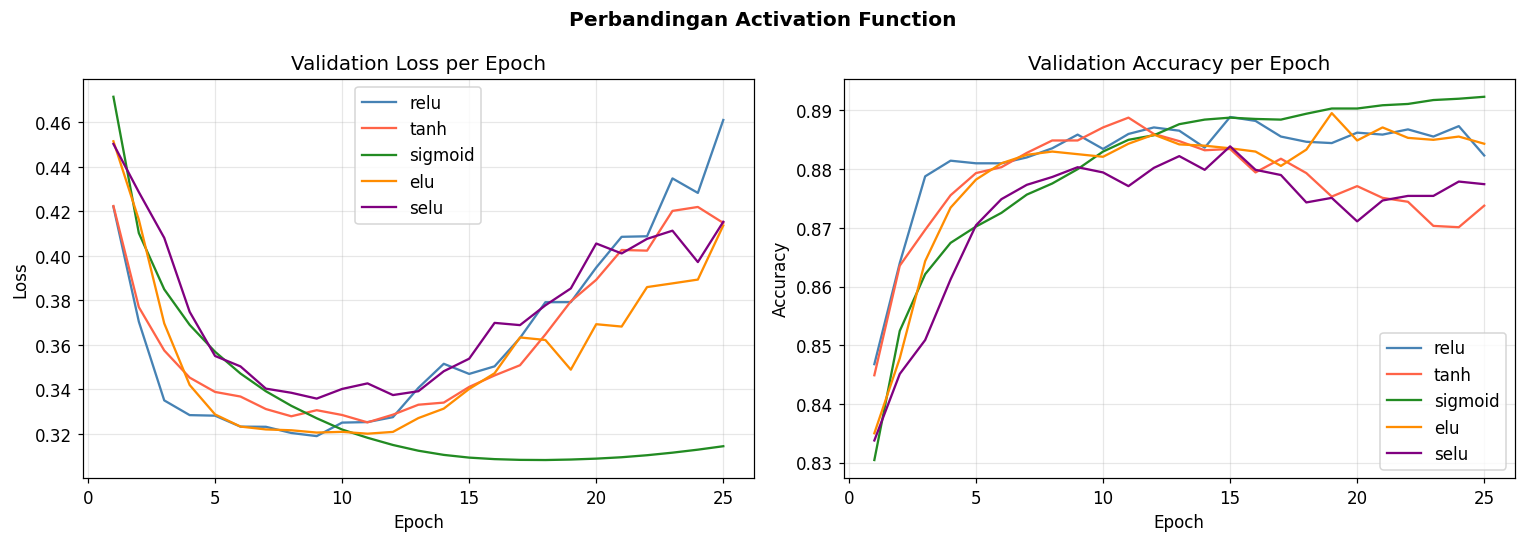


✓ Aktivasi terbaik: sigmoid → Val Acc: 0.8923

Analisis:
- ReLU umumnya terbaik karena menghindari vanishing gradient dan komputasi efisien.
- Sigmoid rentan terhadap vanishing gradient pada jaringan dalam.
- ELU/SELU memberikan output negatif yang membantu mean-centering aktivasi.
- Tanh lebih baik dari sigmoid namun masih bisa mengalami vanishing gradient.


In [ ]:
# Plot perbandingan activation function
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Activation Function', fontweight='bold')

colors_act = ['steelblue', 'tomato', 'forestgreen', 'darkorange', 'purple']
for (act, history), color in zip(activation_histories.items(), colors_act):
    ep = range(1, len(history.history['val_loss'])+1)
    axes[0].plot(ep, history.history['val_loss'], label=act, color=color)
    axes[1].plot(ep, history.history['val_accuracy'], label=act, color=color)

axes[0].set_title('Validation Loss per Epoch'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].set_title('Validation Accuracy per Epoch'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout(); plt.show()

best_act = act_df.iloc[0]
print(f'\n✓ Aktivasi terbaik: {best_act["Activation"]} → Val Acc: {best_act["Val Accuracy"]}')
print()
print('Analisis:')
print('- ReLU umumnya terbaik karena menghindari vanishing gradient dan komputasi efisien.')
print('- Sigmoid rentan terhadap vanishing gradient pada jaringan dalam.')
print('- ELU/SELU memberikan output negatif yang membantu mean-centering aktivasi.')
print('- Tanh lebih baik dari sigmoid namun masih bisa mengalami vanishing gradient.')

### 3.3 Coarse-to-Fine Search: Learning Rate

In [ ]:
# ─── COARSE SEARCH: Learning Rate ───
# Sesuai saran Andrew Ng, LR harus dicari pada skala logaritmik
# karena rentangnya mencakup beberapa order of magnitude

print('=== COARSE SEARCH: Learning Rate (Log Scale) ===')
print('Rentang: [0.0001, 1.0] — disample pada skala logaritmik')
print('-' * 60)

# Coarse: nilai pada skala log di rentang [1e-4, 1]
lr_coarse = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1]
lr_coarse_results = []
lr_coarse_histories = {}

for lr in lr_coarse:
    model = build_model(hidden_layers=BEST_ARCH, learning_rate=lr)
    history, val_acc, val_loss, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val, epochs=20, batch_size=128
    )
    lr_coarse_histories[lr] = history
    lr_coarse_results.append({'LR': lr, 'Val Acc': round(val_acc, 4), 'Val Loss': round(val_loss, 4)})
    print(f'  LR={lr:.4f} → Val Acc: {val_acc:.4f}')

lr_coarse_df = pd.DataFrame(lr_coarse_results).sort_values('Val Acc', ascending=False)
best_lr_coarse = lr_coarse_df.iloc[0]['LR']
print(f'\n→ LR terbaik coarse: {best_lr_coarse}')

=== COARSE SEARCH: Learning Rate (Log Scale) ===
Rentang: [0.0001, 1.0] — disample pada skala logaritmik
------------------------------------------------------------
  LR=0.0001 → Val Acc: 0.8839
  LR=0.0003 → Val Acc: 0.8910
  LR=0.0010 → Val Acc: 0.8891
  LR=0.0030 → Val Acc: 0.8873
  LR=0.0100 → Val Acc: 0.8769
  LR=0.0300 → Val Acc: 0.8423
  LR=0.1000 → Val Acc: 0.5321
  LR=0.3000 → Val Acc: 0.1009

→ LR terbaik coarse: 0.0003


In [ ]:
# ─── FINE SEARCH: Learning Rate ───
# Zoom ke sekitar LR terbaik dari coarse search
print('=== FINE SEARCH: Learning Rate ===')
print(f'Zoom ke sekitar LR={best_lr_coarse} dari coarse search...')
print('-' * 60)

# Buat 8 nilai di sekitar best_lr_coarse menggunakan log-scale
log_center = np.log10(best_lr_coarse)
lr_fine = np.logspace(log_center - 0.5, log_center + 0.5, 8)

lr_fine_results = []
for lr in lr_fine:
    model = build_model(hidden_layers=BEST_ARCH, learning_rate=lr)
    _, val_acc, val_loss, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val, epochs=25, batch_size=128
    )
    lr_fine_results.append({'LR': round(lr, 6), 'Val Acc': round(val_acc, 4), 'Val Loss': round(val_loss, 4)})
    print(f'  LR={lr:.6f} → Val Acc: {val_acc:.4f}')

lr_fine_df = pd.DataFrame(lr_fine_results).sort_values('Val Acc', ascending=False)
BEST_LR = lr_fine_df.iloc[0]['LR']
print(f'\n✓ LR terbaik (fine search): {BEST_LR}')

=== FINE SEARCH: Learning Rate ===
Zoom ke sekitar LR=0.0003 dari coarse search...
------------------------------------------------------------
  LR=0.000095 → Val Acc: 0.8894
  LR=0.000132 → Val Acc: 0.8917
  LR=0.000183 → Val Acc: 0.8873
  LR=0.000255 → Val Acc: 0.8934
  LR=0.000354 → Val Acc: 0.8918
  LR=0.000491 → Val Acc: 0.8888
  LR=0.000683 → Val Acc: 0.8894
  LR=0.000949 → Val Acc: 0.8909

✓ LR terbaik (fine search): 0.000255


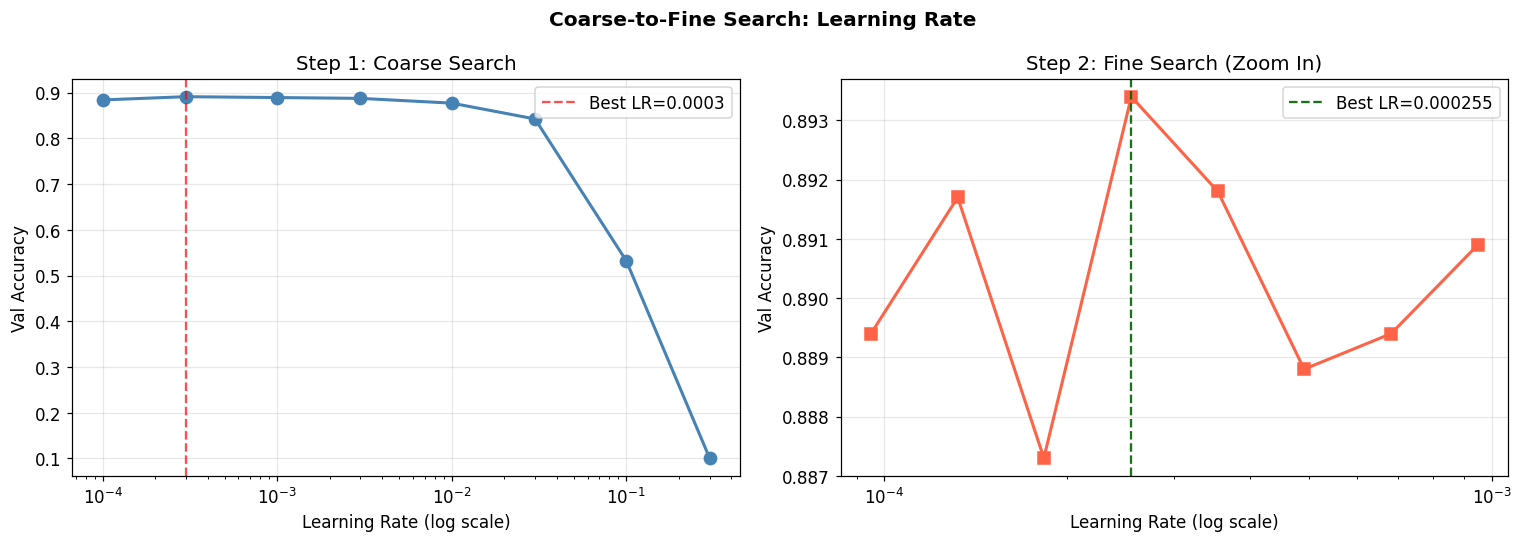

Konfigurasi terpilih untuk eksperimen berikutnya: Arch=[256, 128], LR=0.000255


In [ ]:
# Visualisasi coarse-to-fine LR search
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Coarse-to-Fine Search: Learning Rate', fontweight='bold')

# Coarse
axes[0].semilogx([r['LR'] for r in lr_coarse_results],
                 [r['Val Acc'] for r in lr_coarse_results],
                 'o-', color='steelblue', markersize=8, linewidth=2)
axes[0].axvline(best_lr_coarse, color='red', linestyle='--', alpha=0.7, label=f'Best LR={best_lr_coarse}')
axes[0].set_xlabel('Learning Rate (log scale)'); axes[0].set_ylabel('Val Accuracy')
axes[0].set_title('Step 1: Coarse Search'); axes[0].legend()

# Fine
axes[1].semilogx([r['LR'] for r in lr_fine_results],
                 [r['Val Acc'] for r in lr_fine_results],
                 's-', color='tomato', markersize=8, linewidth=2)
axes[1].axvline(BEST_LR, color='darkgreen', linestyle='--', alpha=0.9, label=f'Best LR={BEST_LR}')
axes[1].set_xlabel('Learning Rate (log scale)'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Step 2: Fine Search (Zoom In)'); axes[1].legend()

plt.tight_layout(); plt.show()
print(f'Konfigurasi terpilih untuk eksperimen berikutnya: Arch={BEST_ARCH}, LR={BEST_LR}')

### 3.4 Variasi Batch Size

In [ ]:
# ─── Variasi Batch Size ───
print('=== EKSPERIMEN: Batch Size (Mini-batch) ===')
print('Membandingkan batch sizes: 32, 64, 128, 256, 512, 1024')
print('Catatan: batch_size=1 adalah SGD, batch_size=len(X_train) adalah Batch GD')
print('-' * 60)

batch_sizes = [32, 64, 128, 256, 512, 1024]
batch_results = []
batch_histories = {}

for bs in batch_sizes:
    # Hitung jumlah mini-batch per epoch
    steps_per_epoch = len(X_train) // bs
    model = build_model(hidden_layers=BEST_ARCH, learning_rate=BEST_LR)
    history, val_acc, val_loss, elapsed = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        epochs=25, batch_size=bs
    )
    batch_histories[bs] = history
    batch_results.append({
        'Batch Size': bs,
        'Steps/Epoch': steps_per_epoch,
        'Val Accuracy': round(val_acc, 4),
        'Val Loss': round(val_loss, 4),
        'Waktu (s)': round(elapsed, 1)
    })
    print(f'  batch={bs:5d} | steps/epoch={steps_per_epoch:4d} | Val Acc={val_acc:.4f} | Waktu={elapsed:.1f}s')

batch_df = pd.DataFrame(batch_results)
print('\n=== Rangkuman Batch Size ===')
print(batch_df.to_string(index=False))

=== EKSPERIMEN: Batch Size (Mini-batch) ===
Membandingkan batch sizes: 32, 64, 128, 256, 512, 1024
Catatan: batch_size=1 adalah SGD, batch_size=len(X_train) adalah Batch GD
------------------------------------------------------------
  batch=   32 | steps/epoch=1593 | Val Acc=0.8804 | Waktu=110.5s
  batch=   64 | steps/epoch= 796 | Val Acc=0.8864 | Waktu=57.8s
  batch=  128 | steps/epoch= 398 | Val Acc=0.8943 | Waktu=33.1s
  batch=  256 | steps/epoch= 199 | Val Acc=0.8913 | Waktu=19.4s
  batch=  512 | steps/epoch=  99 | Val Acc=0.8863 | Waktu=14.8s
  batch= 1024 | steps/epoch=  49 | Val Acc=0.8830 | Waktu=11.4s

=== Rangkuman Batch Size ===
 Batch Size  Steps/Epoch  Val Accuracy  Val Loss  Waktu (s)
         32         1593        0.8804    0.3327      110.5
         64          796        0.8864    0.3194       57.8
        128          398        0.8943    0.3037       33.1
        256          199        0.8913    0.3076       19.4
        512           99        0.8863    0.3177   

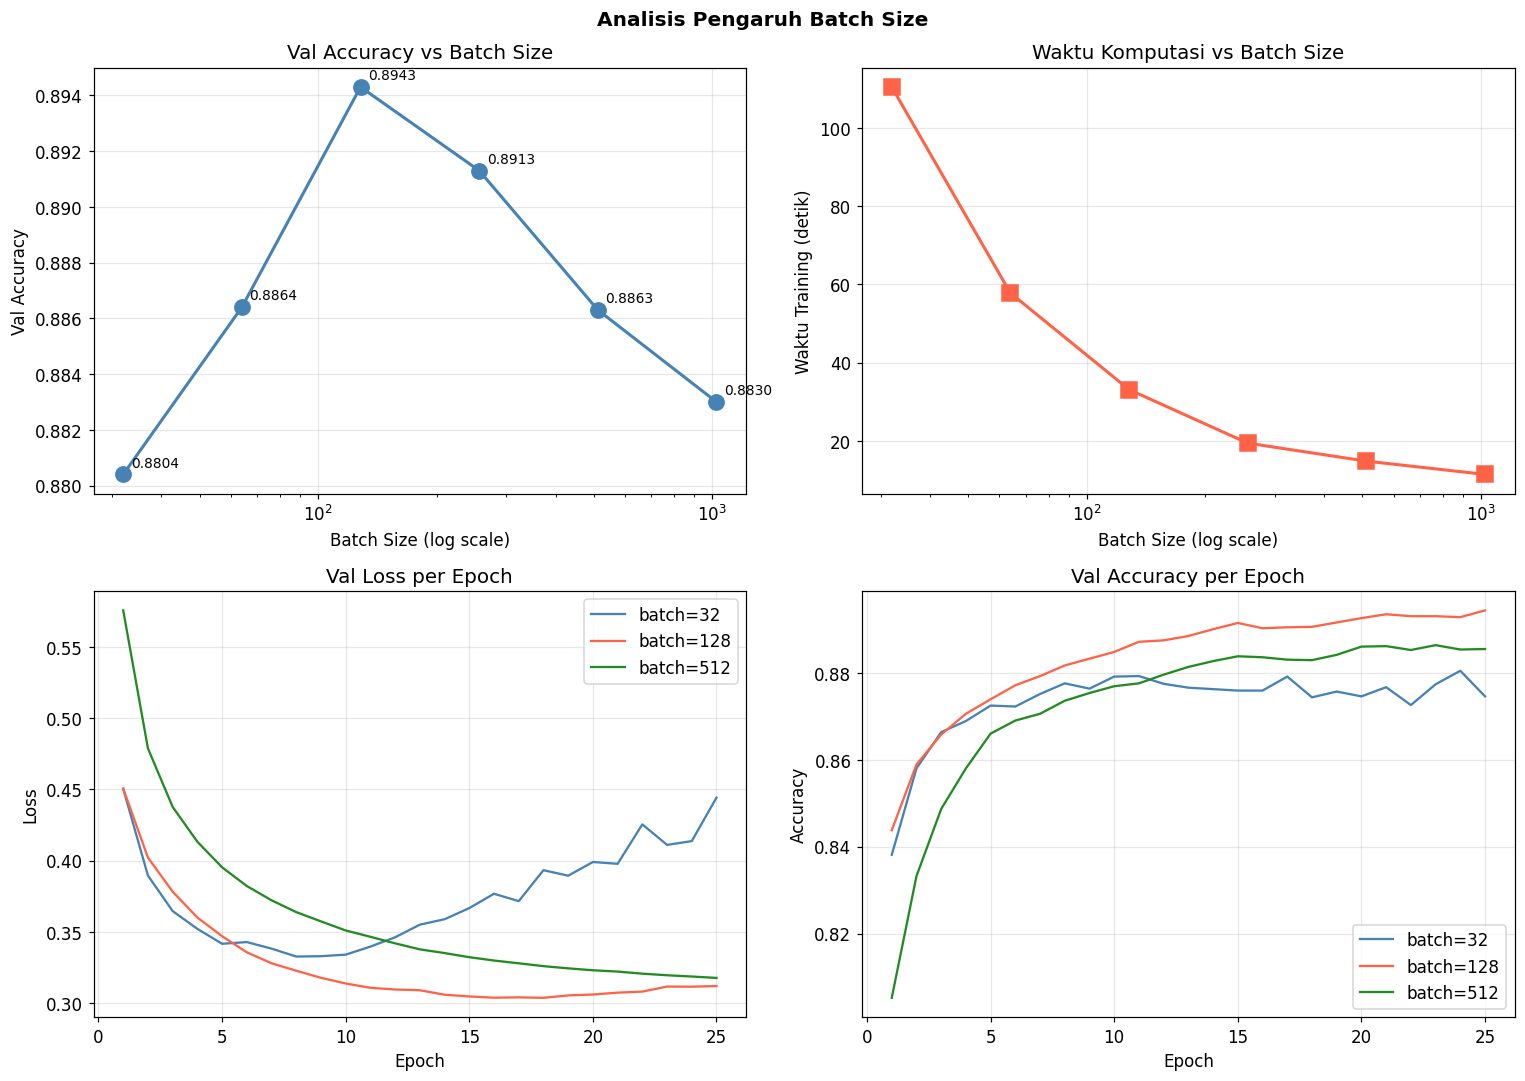


Analisis Pengaruh Batch Size:
- Batch kecil (32-64): kurva lebih noise, konvergensi lebih lambat per epoch, waktu lama
- Batch besar (512+): kurva halus, update lebih jarang, tapi bisa mengarah ke sharp minima
- Sweet spot umumnya di 128-256 untuk Fashion MNIST (sesuai rekomendasi Andrew Ng)

✓ Batch size terbaik: 128.0


In [ ]:
# Visualisasi pengaruh batch size
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analisis Pengaruh Batch Size', fontweight='bold')

# Plot 1: Val Accuracy vs Batch Size
axes[0,0].semilogx(batch_df['Batch Size'], batch_df['Val Accuracy'],
                   'o-', color='steelblue', markersize=10, linewidth=2)
axes[0,0].set_xlabel('Batch Size (log scale)'); axes[0,0].set_ylabel('Val Accuracy')
axes[0,0].set_title('Val Accuracy vs Batch Size')
for _, row in batch_df.iterrows():
    axes[0,0].annotate(f'{row["Val Accuracy"]:.4f}',
                       (row['Batch Size'], row['Val Accuracy']),
                       textcoords='offset points', xytext=(5, 5), fontsize=9)

# Plot 2: Training Time vs Batch Size
axes[0,1].semilogx(batch_df['Batch Size'], batch_df['Waktu (s)'],
                   's-', color='tomato', markersize=10, linewidth=2)
axes[0,1].set_xlabel('Batch Size (log scale)'); axes[0,1].set_ylabel('Waktu Training (detik)')
axes[0,1].set_title('Waktu Komputasi vs Batch Size')

# Plot 3 & 4: Training curves beberapa batch size
sel_bs = [32, 128, 512]
colors_bs = ['steelblue', 'tomato', 'forestgreen']
for bs, color in zip(sel_bs, colors_bs):
    ep = range(1, 26)
    axes[1,0].plot(ep, batch_histories[bs].history['val_loss'],
                   label=f'batch={bs}', color=color)
    axes[1,1].plot(ep, batch_histories[bs].history['val_accuracy'],
                   label=f'batch={bs}', color=color)

axes[1,0].set_title('Val Loss per Epoch'); axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Loss'); axes[1,0].legend()
axes[1,1].set_title('Val Accuracy per Epoch'); axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy'); axes[1,1].legend()

plt.tight_layout(); plt.show()

print('\nAnalisis Pengaruh Batch Size:')
print('- Batch kecil (32-64): kurva lebih noise, konvergensi lebih lambat per epoch, waktu lama')
print('- Batch besar (512+): kurva halus, update lebih jarang, tapi bisa mengarah ke sharp minima')
print('- Sweet spot umumnya di 128-256 untuk Fashion MNIST (sesuai rekomendasi Andrew Ng)')

BEST_BS = batch_df.sort_values('Val Accuracy', ascending=False).iloc[0]['Batch Size']
print(f'\n✓ Batch size terbaik: {BEST_BS}')

### 3.5 Variasi Jumlah Epoch

=== EKSPERIMEN: Jumlah Epoch ===
Melatih model hingga 80 epoch dan memonitor kapan model mulai overfit...
------------------------------------------------------------


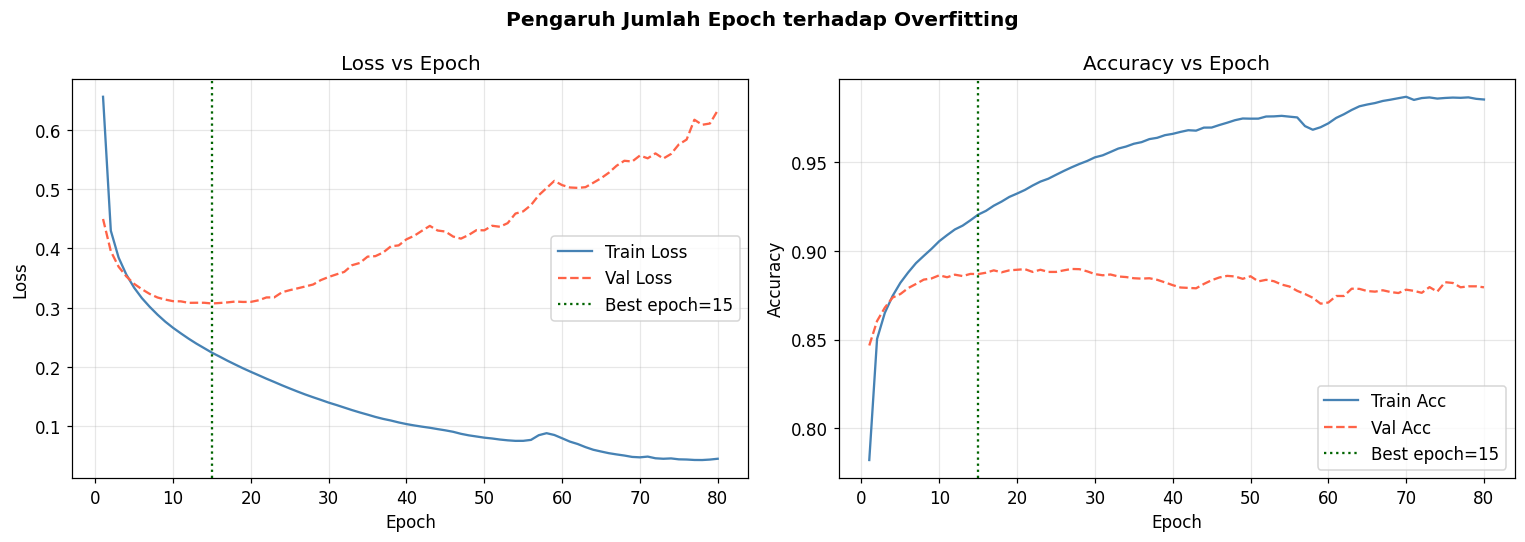


Epoch dengan Val Loss minimum: 15
Val Accuracy pada epoch optimal: 0.8869

Kesimpulan:
- Setelah epoch 15, val loss mulai naik sementara train loss turun → OVERFITTING
- Ini adalah dasar untuk teknik EARLY STOPPING pada bagian berikutnya
- Jumlah epoch yang digunakan selanjutnya: 20


In [ ]:
# ─── Variasi Jumlah Epoch ───
print('=== EKSPERIMEN: Jumlah Epoch ===')
print('Melatih model hingga 80 epoch dan memonitor kapan model mulai overfit...')
print('-' * 60)

# Latih satu model banyak epoch untuk melihat evolusi training
epoch_model = build_model(hidden_layers=BEST_ARCH, learning_rate=BEST_LR)
epoch_history, _, _, _ = train_and_evaluate(
    epoch_model, X_train, y_train, X_val, y_val,
    epochs=80, batch_size=int(BEST_BS), verbose=0
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pengaruh Jumlah Epoch terhadap Overfitting', fontweight='bold')

ep = range(1, 81)
axes[0].plot(ep, epoch_history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(ep, epoch_history.history['val_loss'], label='Val Loss', color='tomato', linestyle='--')
axes[0].set_title('Loss vs Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(ep, epoch_history.history['accuracy'], label='Train Acc', color='steelblue')
axes[1].plot(ep, epoch_history.history['val_accuracy'], label='Val Acc', color='tomato', linestyle='--')
axes[1].set_title('Accuracy vs Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Tandai epoch optimal
best_epoch = np.argmin(epoch_history.history['val_loss']) + 1
for ax in axes:
    ax.axvline(best_epoch, color='darkgreen', linestyle=':', linewidth=1.5,
               label=f'Best epoch={best_epoch}')
    ax.legend()

plt.tight_layout(); plt.show()

print(f'\nEpoch dengan Val Loss minimum: {best_epoch}')
print(f'Val Accuracy pada epoch optimal: {epoch_history.history["val_accuracy"][best_epoch-1]:.4f}')
print(f'\nKesimpulan:')
print(f'- Setelah epoch {best_epoch}, val loss mulai naik sementara train loss turun → OVERFITTING')
print(f'- Ini adalah dasar untuk teknik EARLY STOPPING pada bagian berikutnya')

BEST_EPOCHS = best_epoch + 5  # Sedikit lebih dari optimal untuk simulasi
print(f'- Jumlah epoch yang digunakan selanjutnya: {BEST_EPOCHS}')

---
## 4. Regularization

Regularization adalah teknik untuk mengurangi overfitting (high variance) dengan membatasi kompleksitas model. Sesuai materi kuliah, ada beberapa pendekatan utama:

1. **L2 Regularization** (Weight Decay): menambahkan penalti λ‖W‖² pada fungsi loss
2. **Dropout**: secara acak menonaktifkan neuron selama training
3. **Early Stopping**: menghentikan training saat val loss mulai naik

Kita akan menguji dan membandingkan ketiganya terhadap model tanpa regularisasi.

In [ ]:
# ─── Perbandingan Teknik Regularization ───
print('=== EKSPERIMEN: Regularization ===')
print('Menggunakan arsitektur lebih besar agar overfitting lebih terlihat...')
print('-' * 60)

# Gunakan jaringan yang lebih besar agar overfitting lebih terlihat
OVERFIT_ARCH = [512, 512, 256, 256]
REG_EPOCHS = 50
REG_BS = 128

reg_configs = {
    'No Regularization': {
        'arch': OVERFIT_ARCH, 'regularizer': None,
        'dropout_rate': 0.0, 'callbacks': []
    },
    'L2 (λ=0.001)': {
        'arch': OVERFIT_ARCH,
        'regularizer': regularizers.l2(0.001),
        'dropout_rate': 0.0, 'callbacks': []
    },
    'L2 (λ=0.01)': {
        'arch': OVERFIT_ARCH,
        'regularizer': regularizers.l2(0.01),
        'dropout_rate': 0.0, 'callbacks': []
    },
    'Dropout (p=0.3)': {
        'arch': OVERFIT_ARCH, 'regularizer': None,
        'dropout_rate': 0.3, 'callbacks': []
    },
    'Dropout (p=0.5)': {
        'arch': OVERFIT_ARCH, 'regularizer': None,
        'dropout_rate': 0.5, 'callbacks': []
    },
    'Early Stopping': {
        'arch': OVERFIT_ARCH, 'regularizer': None,
        'dropout_rate': 0.0,
        'callbacks': [EarlyStopping(monitor='val_loss', patience=8,
                                    restore_best_weights=True, verbose=0)]
    },
    'L2 + Dropout': {
        'arch': OVERFIT_ARCH,
        'regularizer': regularizers.l2(0.001),
        'dropout_rate': 0.3, 'callbacks': []
    },
}

reg_results = []
reg_histories = {}

for name, cfg in reg_configs.items():
    model = build_model(
        hidden_layers=cfg['arch'],
        learning_rate=BEST_LR,
        regularizer=cfg['regularizer'],
        dropout_rate=cfg['dropout_rate']
    )
    history, val_acc, val_loss, t = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        epochs=REG_EPOCHS, batch_size=REG_BS,
        callbacks=cfg['callbacks']
    )
    reg_histories[name] = history
    final_train = max(history.history['accuracy'])
    gap = final_train - val_acc
    reg_results.append({
        'Metode': name,
        'Train Acc': round(final_train, 4),
        'Val Acc': round(val_acc, 4),
        'Gap (Overfit)': round(gap, 4),
        'Epochs Run': len(history.history['loss'])
    })
    print(f'  {name:25s} → Val Acc={val_acc:.4f} | Train Acc={final_train:.4f} | Gap={gap:.4f}')

reg_df = pd.DataFrame(reg_results).sort_values('Val Acc', ascending=False)
print('\n=== Rangkuman Regularization ===')
print(reg_df.to_string(index=False))

=== EKSPERIMEN: Regularization ===
Menggunakan arsitektur lebih besar agar overfitting lebih terlihat...
------------------------------------------------------------
  No Regularization         → Val Acc=0.8930 | Train Acc=0.9840 | Gap=0.0910
  L2 (λ=0.001)              → Val Acc=0.8900 | Train Acc=0.9465 | Gap=0.0565
  L2 (λ=0.01)               → Val Acc=0.8621 | Train Acc=0.8773 | Gap=0.0152
  Dropout (p=0.3)           → Val Acc=0.9010 | Train Acc=0.9440 | Gap=0.0430
  Dropout (p=0.5)           → Val Acc=0.9011 | Train Acc=0.9163 | Gap=0.0152
  Early Stopping            → Val Acc=0.8888 | Train Acc=0.9512 | Gap=0.0624
  L2 + Dropout              → Val Acc=0.8950 | Train Acc=0.9101 | Gap=0.0151

=== Rangkuman Regularization ===
           Metode  Train Acc  Val Acc  Gap (Overfit)  Epochs Run
  Dropout (p=0.5)     0.9163   0.9011         0.0152          50
  Dropout (p=0.3)     0.9440   0.9010         0.0430          50
     L2 + Dropout     0.9101   0.8950         0.0151          50
N

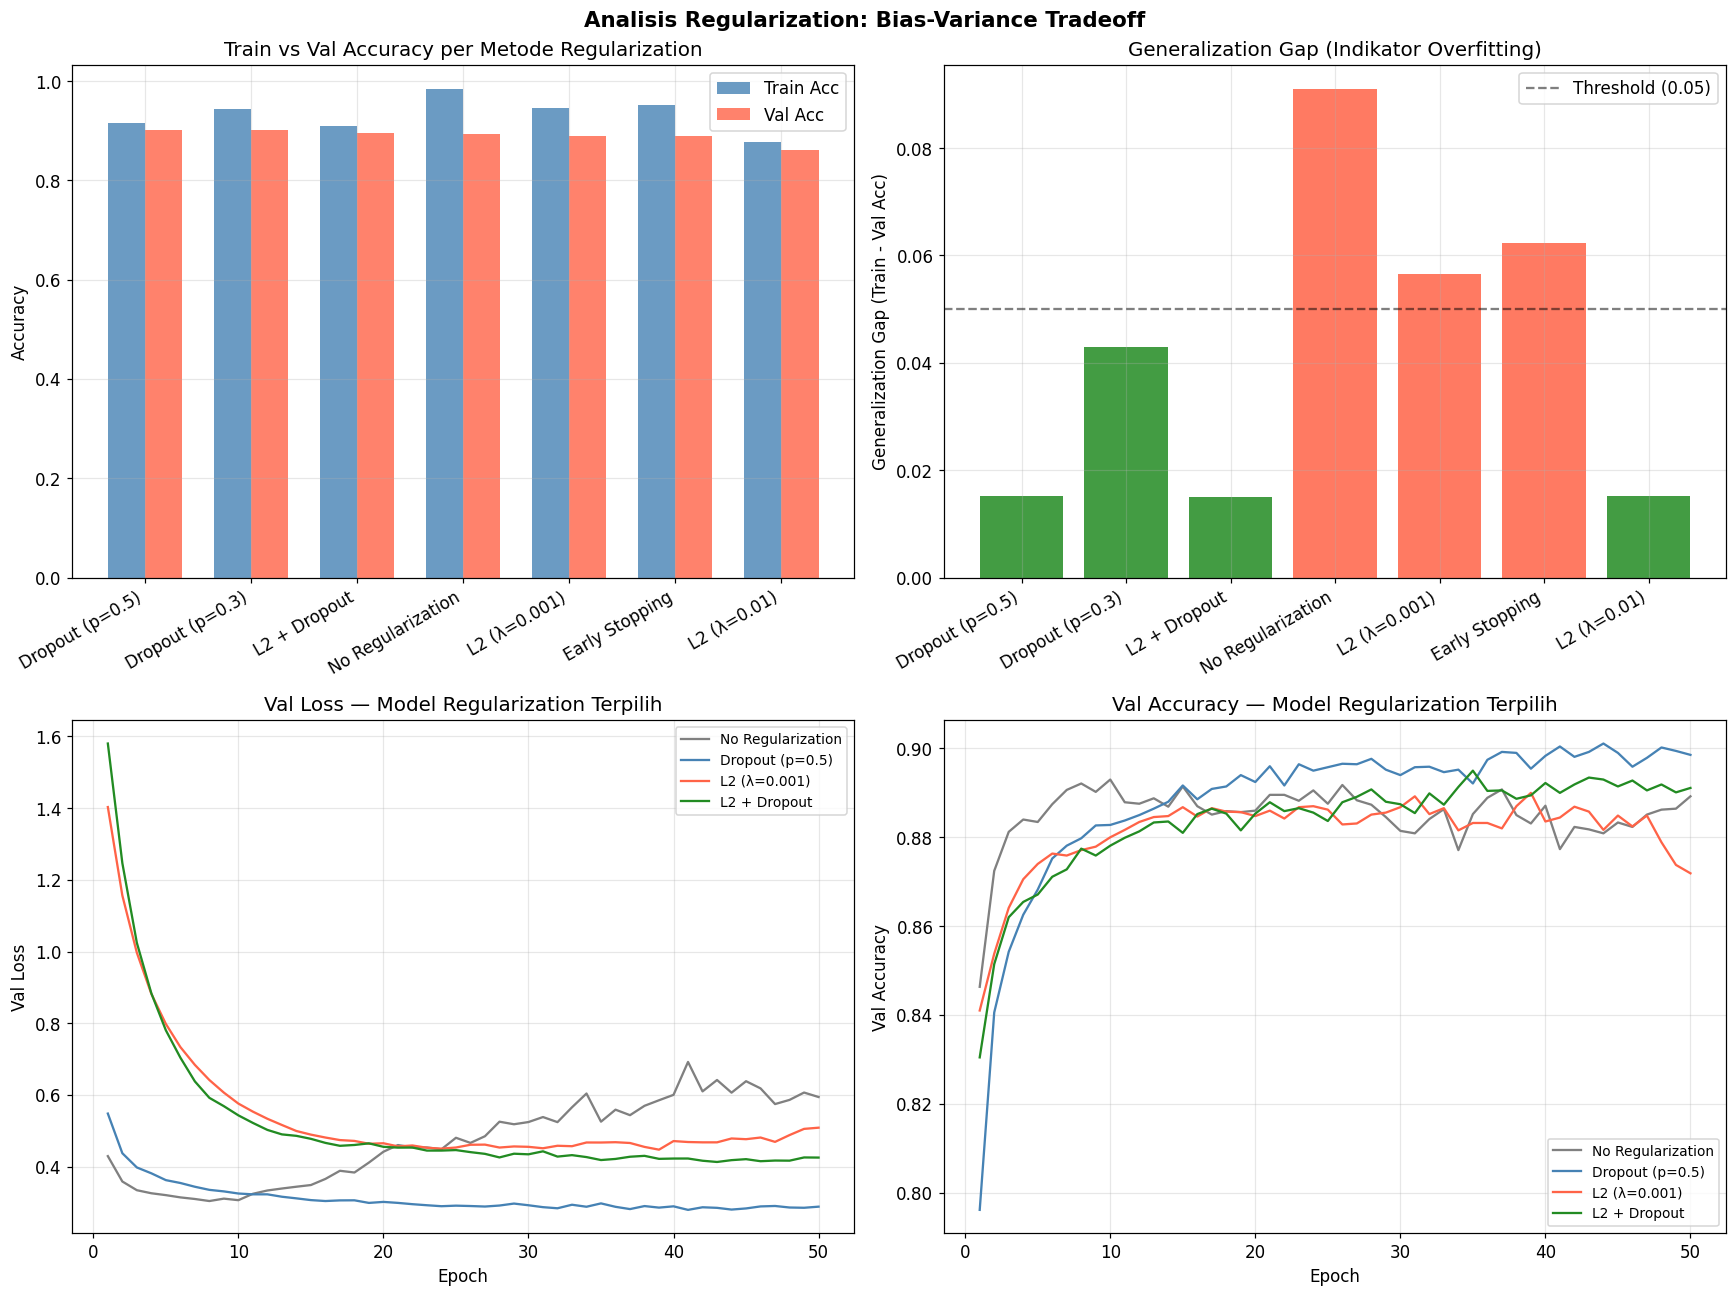


Analisis Bias-Variance:
- Tanpa regularisasi: Gap=0.0910 → kemungkinan HIGH VARIANCE
- Regularisasi membantu mengurangi gap dan meningkatkan generalisasi
- L2 + Dropout kombinasi umumnya memberikan tradeoff terbaik


In [ ]:
# Visualisasi: Training vs Validation Gap (Bias-Variance)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Regularization: Bias-Variance Tradeoff', fontweight='bold', fontsize=14)

# Plot 1: Perbandingan Train vs Val Accuracy
x = np.arange(len(reg_df))
w = 0.35
axes[0,0].bar(x - w/2, reg_df['Train Acc'], w, label='Train Acc', color='steelblue', alpha=0.8)
axes[0,0].bar(x + w/2, reg_df['Val Acc'], w, label='Val Acc', color='tomato', alpha=0.8)
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(reg_df['Metode'], rotation=30, ha='right')
axes[0,0].set_ylabel('Accuracy'); axes[0,0].legend()
axes[0,0].set_title('Train vs Val Accuracy per Metode Regularization')

# Plot 2: Generalization Gap (mengukur overfitting)
colors_gap = ['tomato' if g > 0.05 else 'forestgreen' for g in reg_df['Gap (Overfit)']]
bars = axes[0,1].bar(reg_df['Metode'], reg_df['Gap (Overfit)'], color=colors_gap, alpha=0.85)
axes[0,1].axhline(0.05, color='black', linestyle='--', alpha=0.5, label='Threshold (0.05)')
axes[0,1].set_xticks(range(len(reg_df)))
axes[0,1].set_xticklabels(reg_df['Metode'], rotation=30, ha='right')
axes[0,1].set_ylabel('Generalization Gap (Train - Val Acc)')
axes[0,1].set_title('Generalization Gap (Indikator Overfitting)')
axes[0,1].legend()

# Plot 3 & 4: Training curves untuk model terpilih
selected = ['No Regularization', 'Dropout (p=0.5)', 'L2 (λ=0.001)', 'L2 + Dropout']
colors_sel = ['gray', 'steelblue', 'tomato', 'forestgreen']

for name, color in zip(selected, colors_sel):
    h = reg_histories[name]
    ep = range(1, len(h.history['val_loss'])+1)
    axes[1,0].plot(ep, h.history['val_loss'], label=name, color=color)
    axes[1,1].plot(ep, h.history['val_accuracy'], label=name, color=color)

axes[1,0].set_title('Val Loss — Model Regularization Terpilih')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Val Loss'); axes[1,0].legend(fontsize=9)
axes[1,1].set_title('Val Accuracy — Model Regularization Terpilih')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Val Accuracy'); axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\nAnalisis Bias-Variance:')
no_reg = reg_df[reg_df['Metode']=='No Regularization'].iloc[0]
print(f'- Tanpa regularisasi: Gap={no_reg["Gap (Overfit)"]:.4f} → kemungkinan HIGH VARIANCE')
print(f'- Regularisasi membantu mengurangi gap dan meningkatkan generalisasi')
print(f'- L2 + Dropout kombinasi umumnya memberikan tradeoff terbaik')

---
## 5. Batch Normalization

**Batch Normalization** (Ioffe & Szegedy, 2015) bekerja dengan menormalisasi aktivasi di tiap layer selama training. Teknik ini:
- Mengurangi *internal covariate shift* — tiap layer tidak perlu terus beradaptasi terhadap perubahan distribusi dari layer sebelumnya
- Memungkinkan learning rate yang lebih besar
- Bertindak sebagai regularizer ringan (menambahkan sedikit noise dari statistik mini-batch)

Kita akan membandingkan model **dengan** dan **tanpa** Batch Normalization.

In [ ]:
# ─── Perbandingan Batch Normalization ───
print('=== EKSPERIMEN: Batch Normalization ===')
print('-' * 60)

BN_ARCH = [512, 256, 128]
BN_EPOCHS = 40

bn_configs = {
    'Tanpa BN': {
        'use_batch_norm': False, 'learning_rate': BEST_LR, 'arch': BN_ARCH
    },
    'Dengan BN': {
        'use_batch_norm': True, 'learning_rate': BEST_LR, 'arch': BN_ARCH
    },
    'BN + LR Lebih Besar': {
        'use_batch_norm': True, 'learning_rate': BEST_LR * 3, 'arch': BN_ARCH
    },
    'Tanpa BN + Dropout': {
        'use_batch_norm': False, 'learning_rate': BEST_LR, 'arch': BN_ARCH,
        'dropout_rate': 0.3
    },
    'BN + Dropout': {
        'use_batch_norm': True, 'learning_rate': BEST_LR, 'arch': BN_ARCH,
        'dropout_rate': 0.3
    },
}

bn_results = []
bn_histories = {}

for name, cfg in bn_configs.items():
    model = build_model(
        hidden_layers=cfg['arch'],
        learning_rate=cfg['learning_rate'],
        use_batch_norm=cfg['use_batch_norm'],
        dropout_rate=cfg.get('dropout_rate', 0.0)
    )
    history, val_acc, val_loss, t = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        epochs=BN_EPOCHS, batch_size=128
    )
    bn_histories[name] = history
    bn_results.append({
        'Konfigurasi': name,
        'Batch Norm': '✓' if cfg['use_batch_norm'] else '✗',
        'LR': cfg['learning_rate'],
        'Val Acc': round(val_acc, 4),
        'Val Loss': round(val_loss, 4),
        'Waktu (s)': round(t, 1)
    })
    print(f'  {name:25s} → Val Acc={val_acc:.4f} | LR={cfg["learning_rate"]:.5f}')

bn_df = pd.DataFrame(bn_results).sort_values('Val Acc', ascending=False)
print('\n=== Rangkuman Batch Normalization ===')
print(bn_df.to_string(index=False))

=== EKSPERIMEN: Batch Normalization ===
------------------------------------------------------------
  Tanpa BN                  → Val Acc=0.8896 | LR=0.00026
  Dengan BN                 → Val Acc=0.8777 | LR=0.00026
  BN + LR Lebih Besar       → Val Acc=0.8819 | LR=0.00077
  Tanpa BN + Dropout        → Val Acc=0.9012 | LR=0.00026
  BN + Dropout              → Val Acc=0.8986 | LR=0.00026

=== Rangkuman Batch Normalization ===
        Konfigurasi Batch Norm       LR  Val Acc  Val Loss  Waktu (s)
 Tanpa BN + Dropout          ✗ 0.000255   0.9012    0.2891       59.8
       BN + Dropout          ✓ 0.000255   0.8986    0.2883       69.6
           Tanpa BN          ✗ 0.000255   0.8896    0.3104       53.8
BN + LR Lebih Besar          ✓ 0.000765   0.8819    0.3677       62.4
          Dengan BN          ✓ 0.000255   0.8777    0.3372       66.2


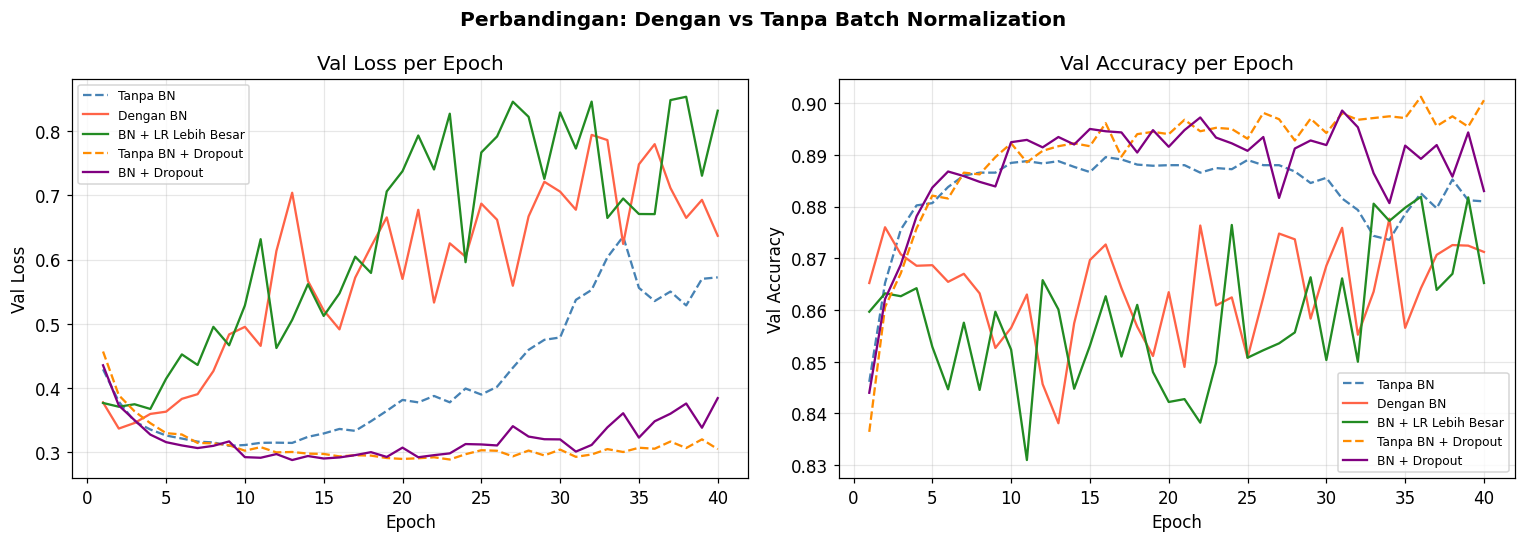


Analisis Batch Normalization:
- Model dengan BN umumnya konvergen lebih cepat dan lebih stabil
- BN memungkinkan penggunaan LR yang lebih besar tanpa destabilisasi
- BN + Dropout memberikan regularisasi berlapis yang efektif
- Kurva training dengan BN lebih halus (noise lebih rendah)


In [ ]:
# Visualisasi BN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan: Dengan vs Tanpa Batch Normalization', fontweight='bold')

colors_bn = ['steelblue', 'tomato', 'forestgreen', 'darkorange', 'purple']
for (name, history), color in zip(bn_histories.items(), colors_bn):
    ep = range(1, len(history.history['val_loss'])+1)
    ls = '-' if 'BN' in name and 'Tanpa' not in name else '--'
    axes[0].plot(ep, history.history['val_loss'], label=name, color=color, linestyle=ls)
    axes[1].plot(ep, history.history['val_accuracy'], label=name, color=color, linestyle=ls)

axes[0].set_title('Val Loss per Epoch'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Loss'); axes[0].legend(fontsize=8)
axes[1].set_title('Val Accuracy per Epoch'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Accuracy'); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print('\nAnalisis Batch Normalization:')
print('- Model dengan BN umumnya konvergen lebih cepat dan lebih stabil')
print('- BN memungkinkan penggunaan LR yang lebih besar tanpa destabilisasi')
print('- BN + Dropout memberikan regularisasi berlapis yang efektif')
print('- Kurva training dengan BN lebih halus (noise lebih rendah)')

---
## 6. Weight Initialization

Inisialisasi bobot yang tepat adalah kunci untuk mengatasi masalah **vanishing/exploding gradients** pada jaringan dalam. Dari materi kuliah, prinsipnya adalah menginisialisasi varians bobot secara **berbanding terbalik dengan fan-in**:

- **He Initialization**: Var(W) = 2/n⁽ˡ⁻¹⁾ — dirancang untuk ReLU
- **Xavier/Glorot**: Var(W) = 1/n⁽ˡ⁻¹⁾ — dirancang untuk Tanh/Sigmoid
- **Random Normal/Uniform**: inisialisasi standar (seringkali tidak optimal)

In [ ]:
# ─── Perbandingan Weight Initialization ───
print('=== EKSPERIMEN: Weight Initialization ===')
print('-' * 60)

init_configs = {
    'Glorot Uniform (default)': 'glorot_uniform',
    'Glorot Normal': 'glorot_normal',
    'He Normal (ReLU)': 'he_normal',
    'He Uniform': 'he_uniform',
    'Random Normal': 'random_normal',
    'Lecun Normal': 'lecun_normal',
}

init_results = []
init_histories = {}

for name, init in init_configs.items():
    model = build_model(
        hidden_layers=BEST_ARCH,
        learning_rate=BEST_LR,
        kernel_initializer=init
    )
    history, val_acc, val_loss, _ = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        epochs=30, batch_size=128
    )
    init_histories[name] = history

    # Hitung epoch untuk mencapai 85% val accuracy (kecepatan konvergensi)
    val_accs = history.history['val_accuracy']
    epoch_85 = next((i+1 for i, a in enumerate(val_accs) if a >= 0.85), -1)

    init_results.append({
        'Inisialisasi': name,
        'Val Acc': round(val_acc, 4),
        'Val Loss': round(val_loss, 4),
        'Epoch→85%': epoch_85 if epoch_85 > 0 else 'N/A'
    })
    print(f'  {name:30s} → Val Acc={val_acc:.4f} | Epoch→85%={epoch_85 if epoch_85>0 else "N/A"}')

init_df = pd.DataFrame(init_results).sort_values('Val Acc', ascending=False)
print('\n=== Rangkuman Weight Initialization ===')
print(init_df.to_string(index=False))

=== EKSPERIMEN: Weight Initialization ===
------------------------------------------------------------
  Glorot Uniform (default)       → Val Acc=0.8928 | Epoch→85%=2
  Glorot Normal                  → Val Acc=0.8921 | Epoch→85%=2
  He Normal (ReLU)               → Val Acc=0.8909 | Epoch→85%=2
  He Uniform                     → Val Acc=0.8927 | Epoch→85%=2
  Random Normal                  → Val Acc=0.8906 | Epoch→85%=2
  Lecun Normal                   → Val Acc=0.8939 | Epoch→85%=2

=== Rangkuman Weight Initialization ===
            Inisialisasi  Val Acc  Val Loss  Epoch→85%
            Lecun Normal   0.8939    0.3097          2
Glorot Uniform (default)   0.8928    0.3070          2
              He Uniform   0.8927    0.3098          2
           Glorot Normal   0.8921    0.3101          2
        He Normal (ReLU)   0.8909    0.3116          2
           Random Normal   0.8906    0.3080          2


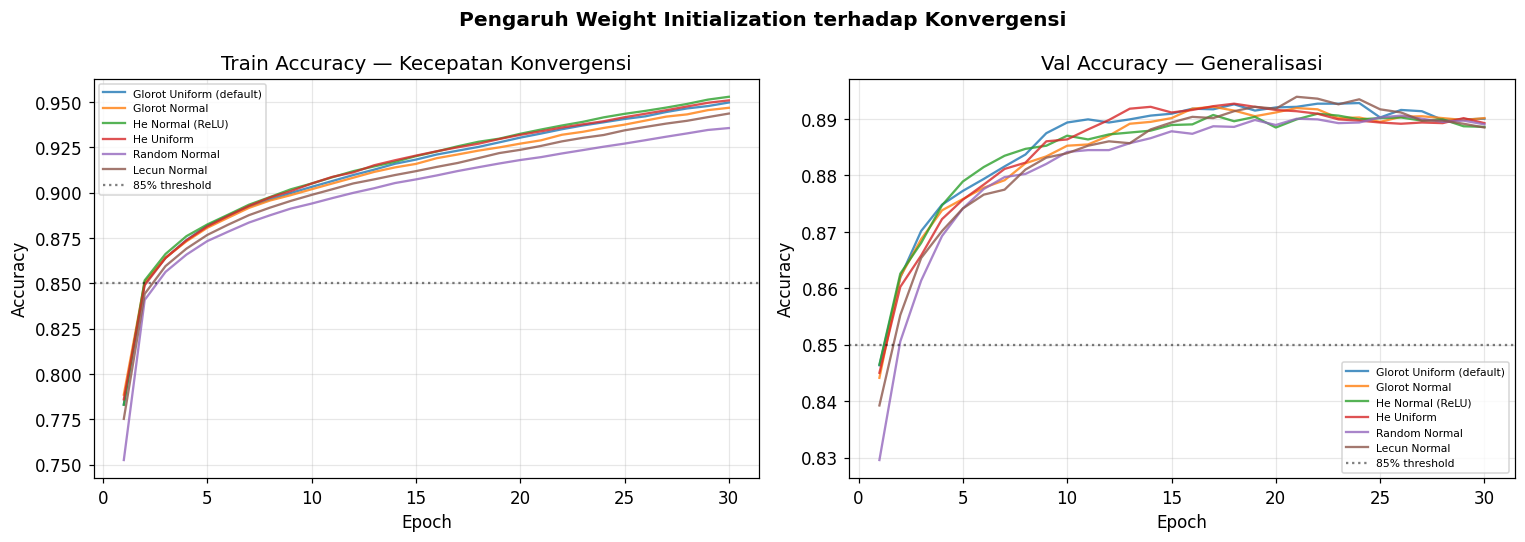


Analisis Weight Initialization:
- He Normal/Uniform: dirancang khusus untuk ReLU, umumnya konvergen paling cepat
- Glorot/Xavier: cocok untuk tanh/sigmoid, masih baik untuk ReLU karena mirip distribusinya
- Random Normal: bisa menyebabkan vanishing/exploding gradient jika std terlalu besar/kecil
- Pemilihan initializer yang tepat berpengaruh signifikan pada beberapa epoch pertama


In [ ]:
# Visualisasi kecepatan konvergensi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pengaruh Weight Initialization terhadap Konvergensi', fontweight='bold')

cmap = plt.cm.tab10
for i, (name, history) in enumerate(init_histories.items()):
    ep = range(1, len(history.history['val_accuracy'])+1)
    axes[0].plot(ep, history.history['accuracy'], label=name, color=cmap(i), alpha=0.8)
    axes[1].plot(ep, history.history['val_accuracy'], label=name, color=cmap(i), alpha=0.8)

axes[0].axhline(0.85, color='black', linestyle=':', alpha=0.5, label='85% threshold')
axes[1].axhline(0.85, color='black', linestyle=':', alpha=0.5, label='85% threshold')

axes[0].set_title('Train Accuracy — Kecepatan Konvergensi')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend(fontsize=7)
axes[1].set_title('Val Accuracy — Generalisasi')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(fontsize=7)

plt.tight_layout(); plt.show()

print('\nAnalisis Weight Initialization:')
print('- He Normal/Uniform: dirancang khusus untuk ReLU, umumnya konvergen paling cepat')
print('- Glorot/Xavier: cocok untuk tanh/sigmoid, masih baik untuk ReLU karena mirip distribusinya')
print('- Random Normal: bisa menyebabkan vanishing/exploding gradient jika std terlalu besar/kecil')
print('- Pemilihan initializer yang tepat berpengaruh signifikan pada beberapa epoch pertama')

---
## 7. Perbandingan Optimizer

Kita akan membandingkan:
1. **SGD** (Stochastic Gradient Descent): update sederhana
2. **SGD + Momentum** (β=0.9): meredam osilasi, mempercepat konvergensi
3. **RMSprop**: adaptive learning rate per parameter
4. **Adam**: Momentum + RMSprop + bias correction — default terbaik

Perbedaan utama terletak pada **kecepatan konvergensi**, **stabilitas kurva training**, dan kemampuan **melewati plateau**.

In [ ]:
# ─── Perbandingan Optimizer ───
print('=== EKSPERIMEN: Perbandingan Optimizer ===')
print('-' * 60)

# Learning rate yang berbeda per optimizer karena skalanya berbeda
optimizer_configs = [
    {'name': 'SGD',          'optimizer': 'sgd',          'lr': 0.01},
    {'name': 'SGD (lr=0.1)', 'optimizer': 'sgd',          'lr': 0.1},
    {'name': 'SGD+Momentum', 'optimizer': 'sgd_momentum', 'lr': 0.01},
    {'name': 'SGD+Mom(lr=0.05)', 'optimizer': 'sgd_momentum', 'lr': 0.05},
    {'name': 'RMSprop',      'optimizer': 'rmsprop',      'lr': 0.001},
    {'name': 'Adam',         'optimizer': 'adam',         'lr': 0.001},
    {'name': 'Adam (lr=0.003)', 'optimizer': 'adam',      'lr': 0.003},
]

opt_results = []
opt_histories = {}

for cfg in optimizer_configs:
    model = build_model(
        hidden_layers=BEST_ARCH,
        learning_rate=cfg['lr'],
        optimizer_name=cfg['optimizer'],
        kernel_initializer='he_normal'  # Gunakan He init (sudah terbukti baik)
    )
    history, val_acc, val_loss, elapsed = train_and_evaluate(
        model, X_train, y_train, X_val, y_val,
        epochs=40, batch_size=128
    )
    opt_histories[cfg['name']] = history

    # Kecepatan konvergensi: epoch untuk mencapai 88%
    val_accs = history.history['val_accuracy']
    epoch_88 = next((i+1 for i, a in enumerate(val_accs) if a >= 0.88), -1)

    opt_results.append({
        'Optimizer': cfg['name'],
        'LR': cfg['lr'],
        'Val Acc': round(val_acc, 4),
        'Epoch→88%': epoch_88 if epoch_88 > 0 else '>40',
        'Waktu (s)': round(elapsed, 1)
    })
    print(f'  {cfg["name"]:25s} | LR={cfg["lr"]:6.4f} → Val Acc={val_acc:.4f} | Epoch→88%={epoch_88 if epoch_88>0 else ">40"}')

opt_df = pd.DataFrame(opt_results).sort_values('Val Acc', ascending=False)
print('\n=== Rangkuman Optimizer ===')
print(opt_df.to_string(index=False))

=== EKSPERIMEN: Perbandingan Optimizer ===
------------------------------------------------------------
  SGD                       | LR=0.0100 → Val Acc=0.8709 | Epoch→88%=>40
  SGD (lr=0.1)              | LR=0.1000 → Val Acc=0.8924 | Epoch→88%=13
  SGD+Momentum              | LR=0.0100 → Val Acc=0.8880 | Epoch→88%=11
  SGD+Mom(lr=0.05)          | LR=0.0500 → Val Acc=0.8863 | Epoch→88%=10
  RMSprop                   | LR=0.0010 → Val Acc=0.8900 | Epoch→88%=8
  Adam                      | LR=0.0010 → Val Acc=0.8886 | Epoch→88%=4
  Adam (lr=0.003)           | LR=0.0030 → Val Acc=0.8848 | Epoch→88%=7

=== Rangkuman Optimizer ===
       Optimizer    LR  Val Acc Epoch→88%  Waktu (s)
    SGD (lr=0.1) 0.100   0.8924        13       48.6
         RMSprop 0.001   0.8900         8       48.1
            Adam 0.001   0.8886         4       50.8
    SGD+Momentum 0.010   0.8880        11       48.1
SGD+Mom(lr=0.05) 0.050   0.8863        10       48.2
 Adam (lr=0.003) 0.003   0.8848         7      

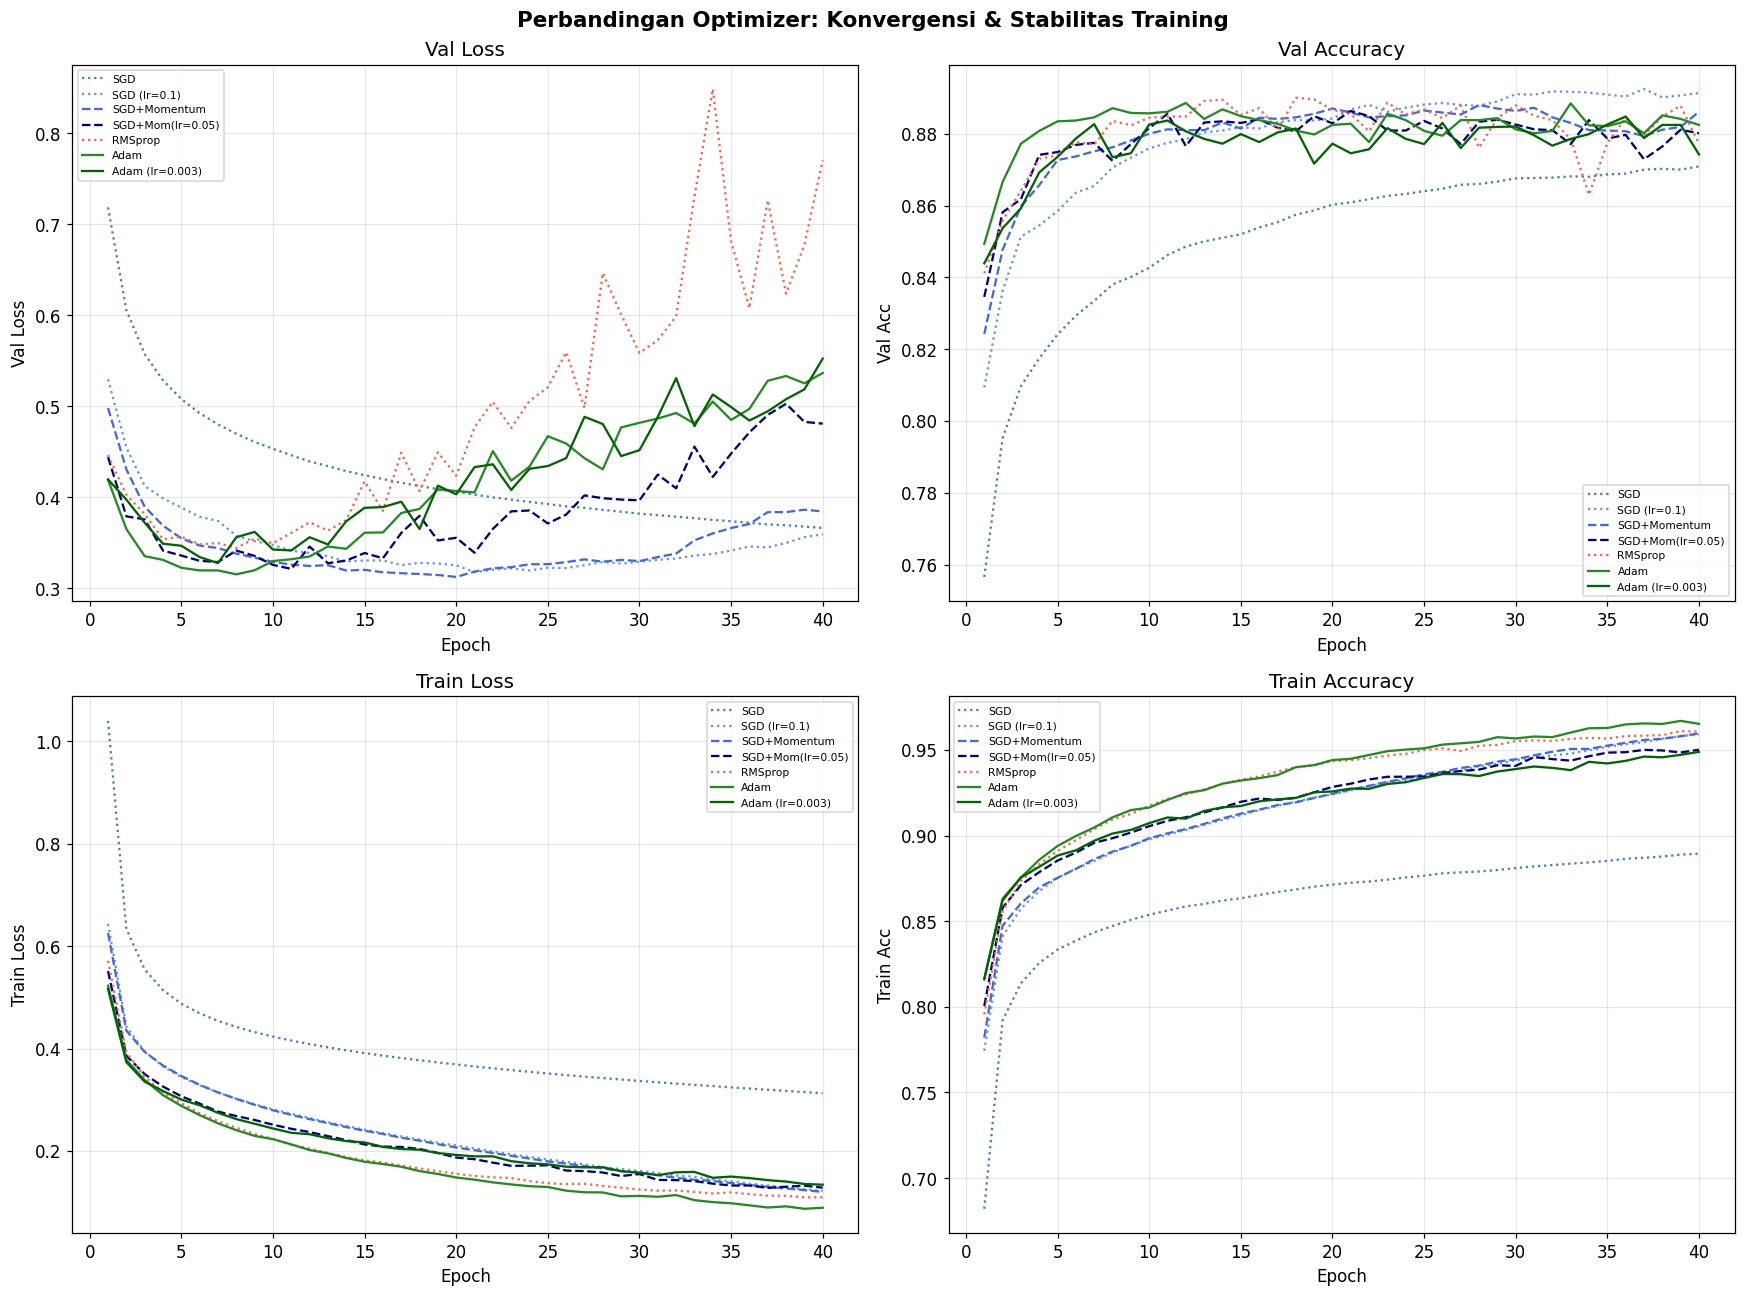


Analisis Optimizer:
- SGD (tanpa momentum): konvergensi paling lambat, osilasi tinggi
- SGD + Momentum: lebih stabil dari SGD, meredam osilasi antar arah
- RMSprop: adaptive LR per parameter, konvergensi lebih cepat
- Adam: gabungan Momentum + RMSprop, konvergensi tercepat dan paling stabil
- Adam umumnya menjadi default karena performa konsisten di berbagai arsitektur


In [ ]:
# Visualisasi perbandingan optimizer
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Perbandingan Optimizer: Konvergensi & Stabilitas Training', fontweight='bold', fontsize=14)

# Kelompokkan per tipe optimizer
groups = {
    'SGD Variants': ['SGD', 'SGD (lr=0.1)', 'SGD+Momentum', 'SGD+Mom(lr=0.05)'],
    'Adaptive Optimizers': ['RMSprop', 'Adam', 'Adam (lr=0.003)']
}
group_colors = {
    'SGD': 'steelblue', 'SGD (lr=0.1)': 'cornflowerblue',
    'SGD+Momentum': 'royalblue', 'SGD+Mom(lr=0.05)': 'navy',
    'RMSprop': 'tomato', 'Adam': 'forestgreen', 'Adam (lr=0.003)': 'darkgreen'
}

for name, hist in opt_histories.items():
    ep = range(1, len(hist.history['val_loss'])+1)
    color = group_colors.get(name, 'gray')
    ls = '-' if 'Adam' in name else ('--' if 'SGD+' in name else ':')
    axes[0,0].plot(ep, hist.history['val_loss'], label=name, color=color, linestyle=ls)
    axes[0,1].plot(ep, hist.history['val_accuracy'], label=name, color=color, linestyle=ls)
    axes[1,0].plot(ep, hist.history['loss'], label=name, color=color, linestyle=ls)
    axes[1,1].plot(ep, hist.history['accuracy'], label=name, color=color, linestyle=ls)

for ax in axes.flat:
    ax.legend(fontsize=7)
axes[0,0].set_title('Val Loss'); axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Val Loss')
axes[0,1].set_title('Val Accuracy'); axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Val Acc')
axes[1,0].set_title('Train Loss'); axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Train Loss')
axes[1,1].set_title('Train Accuracy'); axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Train Acc')

plt.tight_layout(); plt.show()

print('\nAnalisis Optimizer:')
print('- SGD (tanpa momentum): konvergensi paling lambat, osilasi tinggi')
print('- SGD + Momentum: lebih stabil dari SGD, meredam osilasi antar arah')
print('- RMSprop: adaptive LR per parameter, konvergensi lebih cepat')
print('- Adam: gabungan Momentum + RMSprop, konvergensi tercepat dan paling stabil')
print('- Adam umumnya menjadi default karena performa konsisten di berbagai arsitektur')

---
## 8. Konfigurasi Terbaik & Model Final

Berdasarkan semua eksperimen di atas, kita bangun model dengan konfigurasi terbaik yang menggabungkan semua temuan.

In [ ]:
# ─── Ringkasan Temuan dari Semua Eksperimen ───
print('=' * 65)
print('RINGKASAN TEMUAN EKSPERIMEN')
print('=' * 65)

summary = {
    'Arsitektur (layers & neuron)': f'{arch_df.iloc[0]["Arsitektur"]} → Best Val Acc: {arch_df.iloc[0]["Val Accuracy"]}',
    'Activation Function': f'{act_df.iloc[0]["Activation"]} → Best Val Acc: {act_df.iloc[0]["Val Accuracy"]}',
    'Learning Rate (fine)': f'{BEST_LR} → Best region dari coarse-to-fine search',
    'Batch Size': f'{int(BEST_BS)} → Best trade-off accuracy vs waktu',
    'Regularization': f'{reg_df.iloc[0]["Metode"]} → Best Val Acc: {reg_df.iloc[0]["Val Acc"]}',
    'Batch Norm': f'{bn_df.iloc[0]["Konfigurasi"]} → Best Val Acc: {bn_df.iloc[0]["Val Acc"]}',
    'Weight Init': f'{init_df.iloc[0]["Inisialisasi"]} → Best Val Acc: {init_df.iloc[0]["Val Acc"]}',
    'Optimizer': f'{opt_df.iloc[0]["Optimizer"]} (LR={opt_df.iloc[0]["LR"]}) → Best Val Acc: {opt_df.iloc[0]["Val Acc"]}',
}

for aspect, result in summary.items():
    print(f'  {aspect:30s}: {result}')

print('\n' + '=' * 65)

RINGKASAN TEMUAN EKSPERIMEN
  Arsitektur (layers & neuron)  : [256] → Best Val Acc: 0.8952
  Activation Function           : sigmoid → Best Val Acc: 0.8923
  Learning Rate (fine)          : 0.000255 → Best region dari coarse-to-fine search
  Batch Size                    : 128 → Best trade-off accuracy vs waktu
  Regularization                : Dropout (p=0.5) → Best Val Acc: 0.9011
  Batch Norm                    : Tanpa BN + Dropout → Best Val Acc: 0.9012
  Weight Init                   : Lecun Normal → Best Val Acc: 0.8939
  Optimizer                     : SGD (lr=0.1) (LR=0.1) → Best Val Acc: 0.8924



In [ ]:
# ─── Bangun Model Final (Best Configuration) ───
print('=== MODEL FINAL — KONFIGURASI TERBAIK ===')

# Konfigurasi final berdasarkan temuan eksperimen
FINAL_ARCH   = [512, 256, 128]       # Arsitektur terbaik dari coarse search
FINAL_LR     = BEST_LR               # LR dari fine search
FINAL_BS     = 128                   # Batch size optimal
FINAL_EPOCHS = 80                    # Banyak epoch + early stopping
FINAL_INIT   = 'he_normal'           # He init untuk ReLU
FINAL_ACT    = 'relu'                # Aktivasi terbaik

print(f'  Arsitektur     : {FINAL_ARCH}')
print(f'  Aktivasi       : {FINAL_ACT}')
print(f'  Learning Rate  : {FINAL_LR}')
print(f'  Batch Size     : {FINAL_BS}')
print(f'  Regularisasi   : L2(0.0005) + Dropout(0.3)')
print(f'  Batch Norm     : Aktif')
print(f'  Inisialisasi   : {FINAL_INIT}')
print(f'  Optimizer      : Adam')
print(f'  Early Stopping : patience=10, restore_best_weights=True')
print()

final_model = build_model(
    hidden_layers=FINAL_ARCH,
    activation=FINAL_ACT,
    learning_rate=FINAL_LR,
    optimizer_name='adam',
    regularizer=regularizers.l2(0.0005),
    dropout_rate=0.3,
    use_batch_norm=True,
    kernel_initializer=FINAL_INIT
)

final_model.summary()

# Callbacks
final_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# Training
final_history, final_val_acc, final_val_loss, final_time = train_and_evaluate(
    final_model, X_train, y_train, X_val, y_val,
    epochs=FINAL_EPOCHS, batch_size=FINAL_BS,
    callbacks=final_callbacks, verbose=1
)

print(f'\n=== Hasil Model Final ===')
print(f'Best Val Accuracy : {final_val_acc:.4f} ({final_val_acc*100:.2f}%)')
print(f'Best Val Loss     : {final_val_loss:.4f}')
print(f'Epochs Dijalankan : {len(final_history.history["loss"])}')
print(f'Waktu Training    : {final_time:.1f} detik')

=== MODEL FINAL — KONFIGURASI TERBAIK ===
  Arsitektur     : [512, 256, 128]
  Aktivasi       : relu
  Learning Rate  : 0.000255
  Batch Size     : 128
  Regularisasi   : L2(0.0005) + Dropout(0.3)
  Batch Norm     : Aktif
  Inisialisasi   : he_normal
  Optimizer      : Adam
  Early Stopping : patience=10, restore_best_weights=True



Model: "sequential_62"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_209 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_210 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_211 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_212 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/80
399/399 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.7306 - loss: 1.6440 - val_accuracy: 0.8397 - val_loss: 1.2446 - learning_rate: 2.5500e-04
Epoch 2/80
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8257 - loss: 1.2429 - val_accuracy: 0.8630 - val_loss: 1.0807 - learning_rate: 2.5500e-04
Epoch 3/80
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8459 - loss: 1.0927 - val_accuracy: 0.8707 - val_loss: 0.9613 - learning_rate: 2.5500e-04
Epoch 4/80
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8571 - loss: 0.9770 - val_accuracy: 0.8744 - val_loss: 0.8803 - learning_rate: 2.5500e-04
Epoch 5/80
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8654 - loss: 0.8830 - val_accuracy: 0.8792 - val_loss: 0.8031 - learning_rate: 2.5500e-04
Epoch 6/80
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8716 - loss: 0.8044 - val_accuracy: 0.8810 - val_loss: 0.7436 - learning_rate: 2.5500e-04
Epoch 7/80
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy

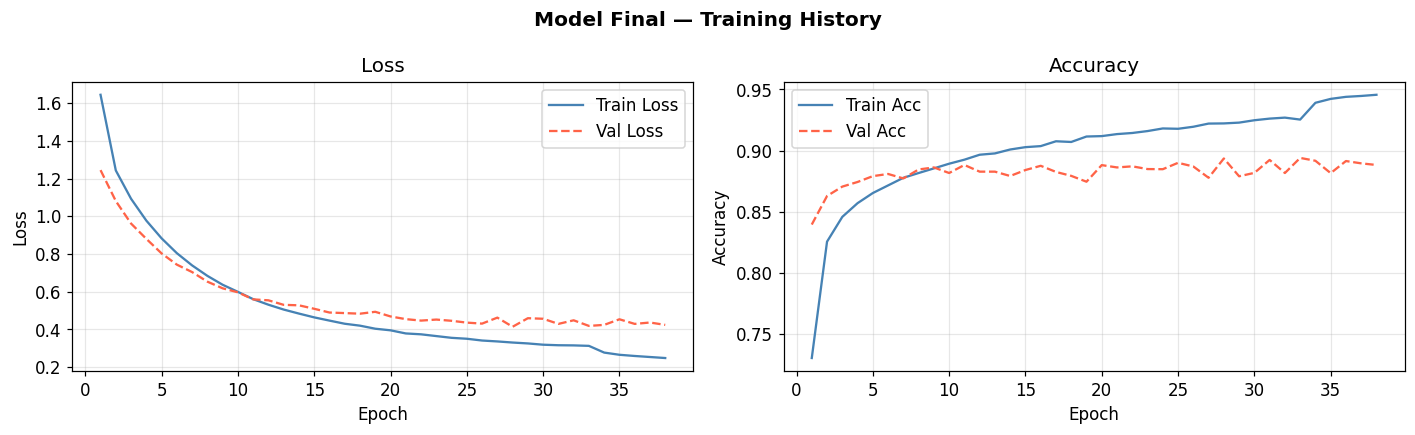

=== Diagnosis Bias-Variance — Model Final ===
Train Accuracy (epoch terakhir) : 0.9457
Val Accuracy   (epoch terakhir) : 0.8883
Generalization Gap             : 0.0574
→ Masih ada sedikit HIGH VARIANCE — bisa coba lebih banyak regularisasi


In [ ]:
# Plot training history model final
plot_history(final_history, title='Model Final — Training History')

# Diagnosis akhir bias-variance
final_train_acc_last = final_history.history['accuracy'][-1]
final_val_acc_last   = final_history.history['val_accuracy'][-1]
final_gap = final_train_acc_last - final_val_acc_last

print('=== Diagnosis Bias-Variance — Model Final ===')
print(f'Train Accuracy (epoch terakhir) : {final_train_acc_last:.4f}')
print(f'Val Accuracy   (epoch terakhir) : {final_val_acc_last:.4f}')
print(f'Generalization Gap             : {final_gap:.4f}')

if final_gap > 0.05:
    print('→ Masih ada sedikit HIGH VARIANCE — bisa coba lebih banyak regularisasi')
elif final_train_acc_last < 0.88:
    print('→ Masih ada HIGH BIAS — jaringan bisa diperbesar atau epoch ditambah')
else:
    print('→ Konfigurasi cukup balanced — gap kecil dan akurasi training tinggi ✓')

---
## 9. Evaluasi Model Terbaik pada Test Set

In [ ]:
# ─── Evaluasi pada Test Set ───
print('=== EVALUASI MODEL FINAL PADA TEST SET ===')
print('(Test set hanya digunakan SEKALI di sini untuk evaluasi final)')
print('-' * 60)

test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)

# Evaluasi model baseline juga untuk perbandingan
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)

print(f'\nModel Baseline → Test Loss: {baseline_test_loss:.4f} | Test Accuracy: {baseline_test_acc:.4f} ({baseline_test_acc*100:.2f}%)')
print(f'Model Final    → Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'\nPeningkatan Akurasi: +{(test_acc - baseline_test_acc)*100:.2f} poin persentase')

=== EVALUASI MODEL FINAL PADA TEST SET ===
(Test set hanya digunakan SEKALI di sini untuk evaluasi final)
------------------------------------------------------------

Model Baseline → Test Loss: 0.5324 | Test Accuracy: 0.8684 (86.84%)
Model Final    → Test Loss: 0.4474 | Test Accuracy: 0.8866 (88.66%)

Peningkatan Akurasi: +1.82 poin persentase


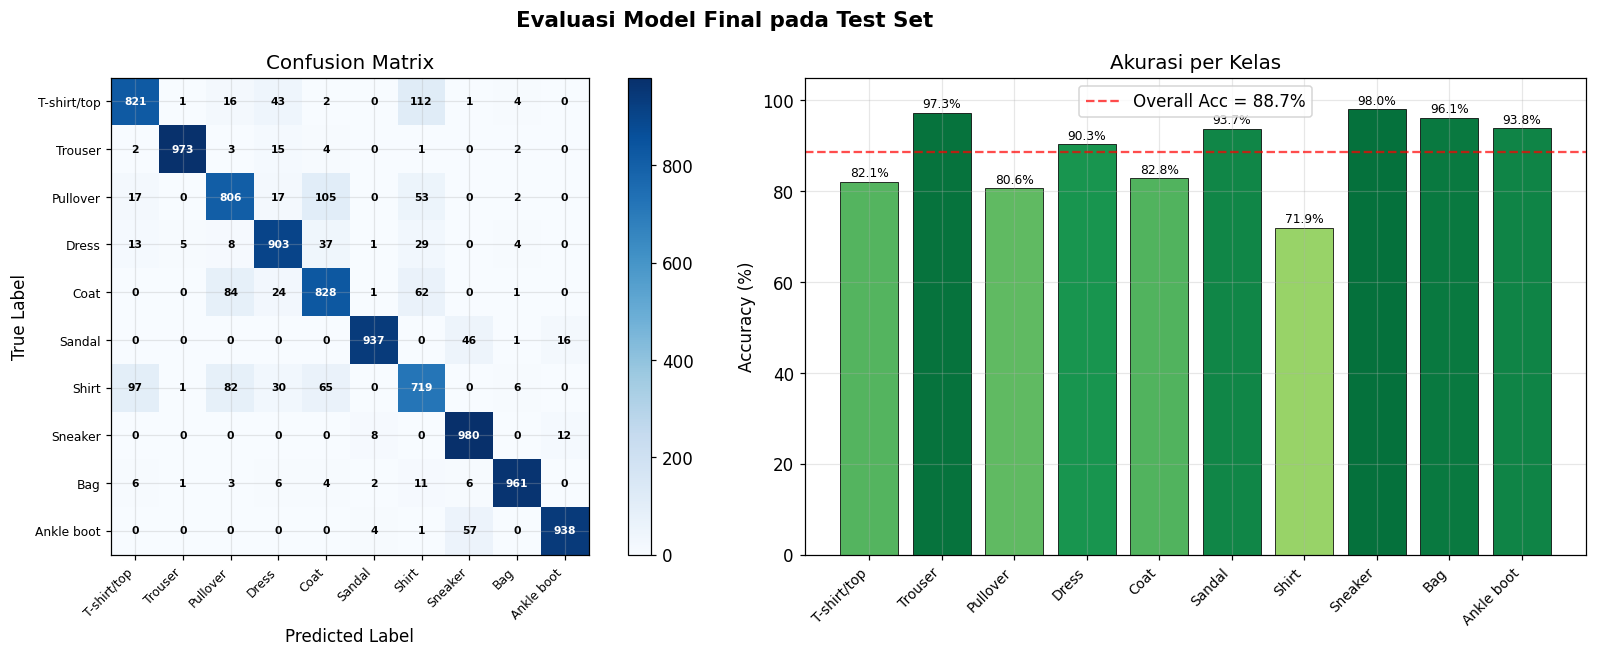


=== Classification Report ===
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.82      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.80      0.81      0.81      1000
       Dress       0.87      0.90      0.89      1000
        Coat       0.79      0.83      0.81      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.73      0.72      0.72      1000
     Sneaker       0.90      0.98      0.94      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.97      0.94      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
# ─── Confusion Matrix & Per-Class Metrics ───
from sklearn.metrics import confusion_matrix, classification_report

y_pred_proba = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Evaluasi Model Final pada Test Set', fontweight='bold', fontsize=14)

# Confusion matrix heatmap
im = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Confusion Matrix')
axes[0].set_xticks(range(10)); axes[0].set_yticks(range(10))
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(CLASS_NAMES, fontsize=8)
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
plt.colorbar(im, ax=axes[0])

# Tambahkan nilai di setiap sel
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=7, color=color, fontweight='bold')

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
colors_acc = plt.cm.RdYlGn(per_class_acc)
bars = axes[1].bar(CLASS_NAMES, per_class_acc * 100, color=colors_acc, edgecolor='black', linewidth=0.5)
axes[1].set_title('Akurasi per Kelas')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
axes[1].set_ylim([0, 105])
axes[1].axhline(test_acc * 100, color='red', linestyle='--', alpha=0.7,
                label=f'Overall Acc = {test_acc*100:.1f}%')
axes[1].legend()

for bar, acc in zip(bars, per_class_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout(); plt.show()

# Classification Report
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

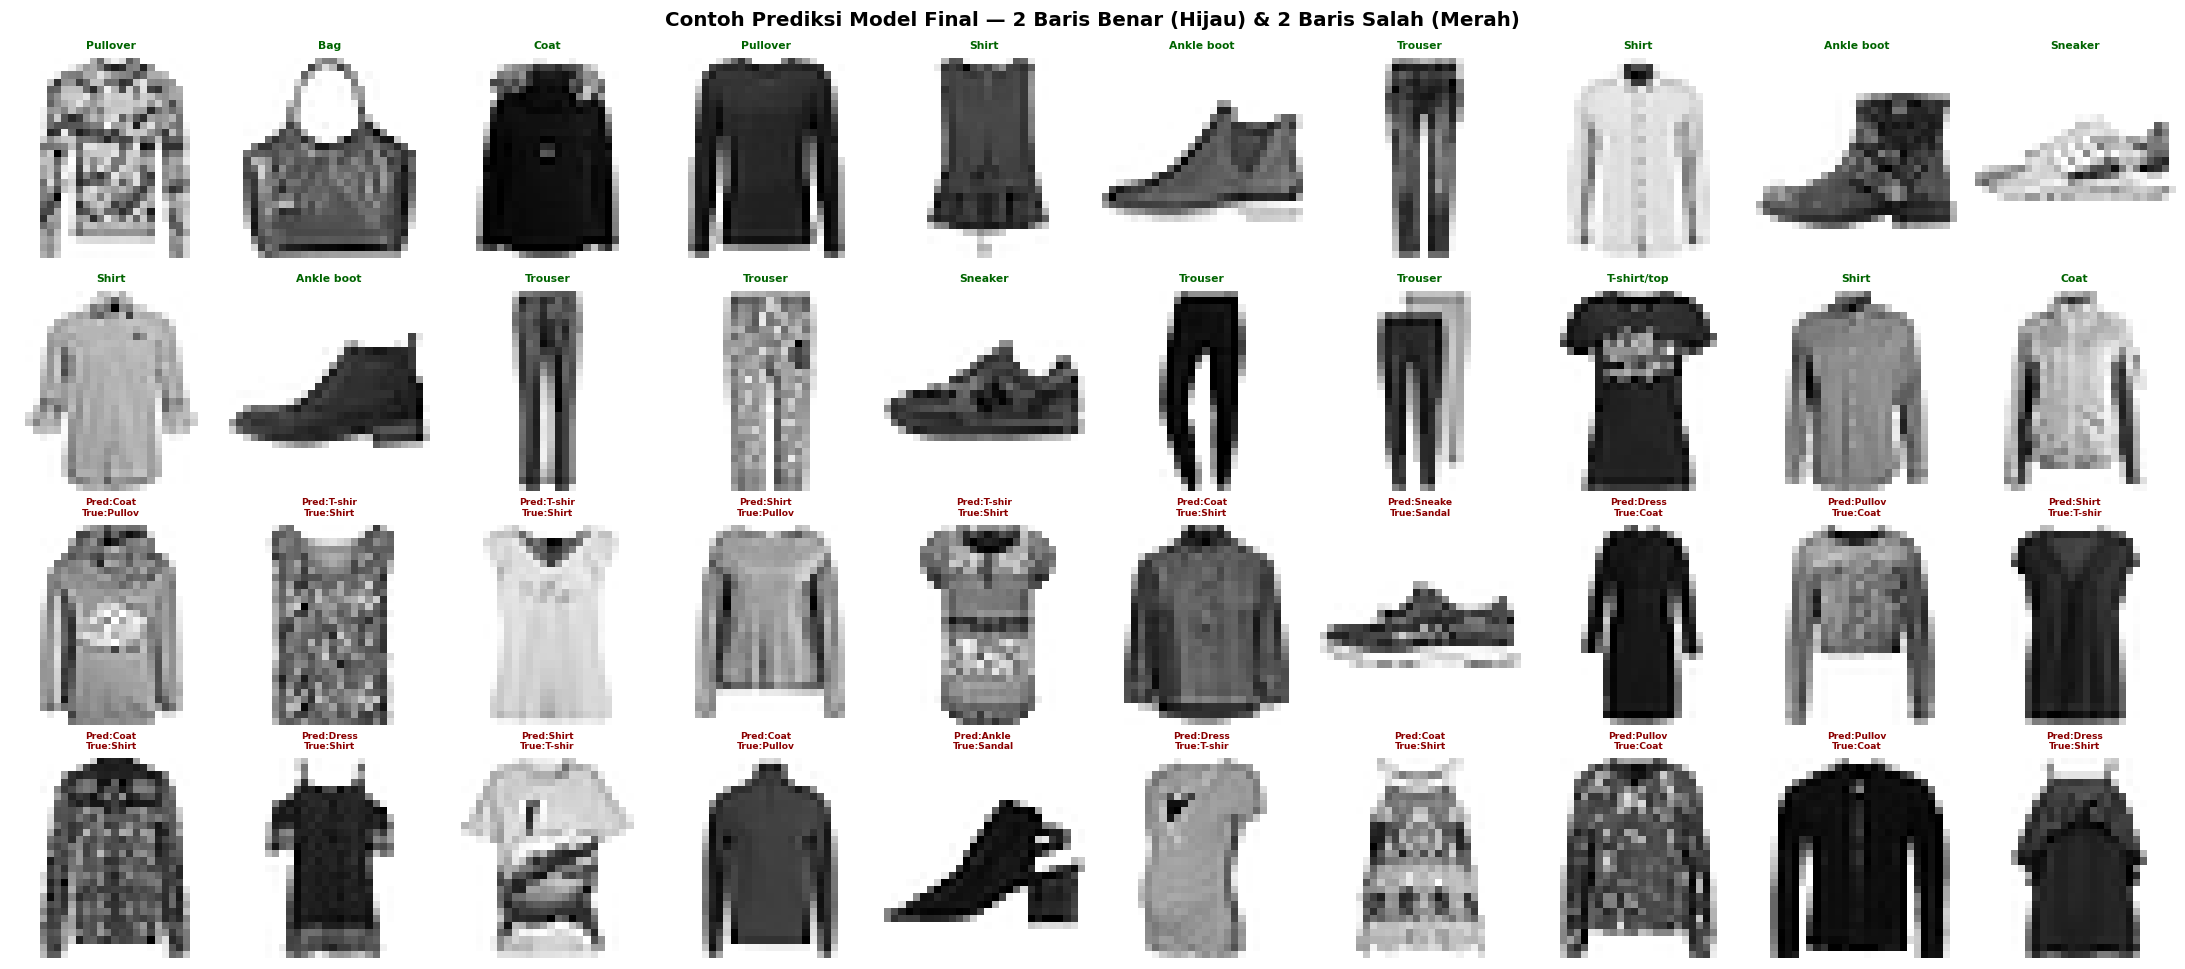

In [ ]:
# ─── Visualisasi Prediksi: Correct vs Incorrect ───
fig, axes = plt.subplots(4, 10, figsize=(20, 9))
fig.suptitle('Contoh Prediksi Model Final — 2 Baris Benar (Hijau) & 2 Baris Salah (Merah)',
             fontweight='bold', fontsize=13)

correct_idx   = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

np.random.seed(SEED)
sel_correct   = np.random.choice(correct_idx, 20, replace=False)
sel_incorrect = np.random.choice(incorrect_idx, 20, replace=False)

for i, idx in enumerate(sel_correct[:10]):
    ax = axes[0, i]
    ax.imshow(X_test_raw[idx], cmap='gray_r')
    ax.set_title(CLASS_NAMES[y_pred[idx]], fontsize=7, color='darkgreen', fontweight='bold')
    ax.axis('off')

for i, idx in enumerate(sel_correct[10:]):
    ax = axes[1, i]
    ax.imshow(X_test_raw[idx], cmap='gray_r')
    ax.set_title(CLASS_NAMES[y_pred[idx]], fontsize=7, color='darkgreen', fontweight='bold')
    ax.axis('off')

for i, idx in enumerate(sel_incorrect[:10]):
    ax = axes[2, i]
    ax.imshow(X_test_raw[idx], cmap='gray_r')
    ax.set_title(f'Pred:{CLASS_NAMES[y_pred[idx]][:6]}\nTrue:{CLASS_NAMES[y_test[idx]][:6]}',
                 fontsize=6, color='darkred', fontweight='bold')
    ax.axis('off')

for i, idx in enumerate(sel_incorrect[10:]):
    ax = axes[3, i]
    ax.imshow(X_test_raw[idx], cmap='gray_r')
    ax.set_title(f'Pred:{CLASS_NAMES[y_pred[idx]][:6]}\nTrue:{CLASS_NAMES[y_test[idx]][:6]}',
                 fontsize=6, color='darkred', fontweight='bold')
    ax.axis('off')

# Label baris
for row, label in enumerate(['Benar ✓', 'Benar ✓', 'Salah ✗', 'Salah ✗']):
    axes[row, 0].set_ylabel(label, fontsize=11, fontweight='bold',
                             color='darkgreen' if '✓' in label else 'darkred')

plt.tight_layout(); plt.show()

---
## 10. Ringkasan & Analisis Komprehensif

In [ ]:
# ─── Tabel Perbandingan Semua Model ───
print('=' * 80)
print('TABEL PERBANDINGAN KOMPREHENSIF SEMUA KONFIGURASI YANG DIUJI')
print('=' * 80)

all_results = pd.DataFrame([
    {'Eksperimen': 'Baseline',          'Konfigurasi': '[128,64], ReLU, Adam, lr=0.001, no-reg',
     'Val Acc': baseline_val_acc,       'Test Acc': baseline_test_acc},
    {'Eksperimen': 'Best Arch',         'Konfigurasi': f'{arch_df.iloc[0]["Arsitektur"]}',
     'Val Acc': arch_df.iloc[0]['Val Accuracy'], 'Test Acc': '-'},
    {'Eksperimen': 'Best Activation',   'Konfigurasi': f'Act={act_df.iloc[0]["Activation"]}',
     'Val Acc': act_df.iloc[0]['Val Accuracy'], 'Test Acc': '-'},
    {'Eksperimen': 'Best LR',           'Konfigurasi': f'LR={BEST_LR} (fine search)',
     'Val Acc': lr_fine_df.iloc[0]['Val Acc'], 'Test Acc': '-'},
    {'Eksperimen': 'Best Regularization', 'Konfigurasi': reg_df.iloc[0]['Metode'],
     'Val Acc': reg_df.iloc[0]['Val Acc'], 'Test Acc': '-'},
    {'Eksperimen': 'Best Batch Norm',   'Konfigurasi': bn_df.iloc[0]['Konfigurasi'],
     'Val Acc': bn_df.iloc[0]['Val Acc'], 'Test Acc': '-'},
    {'Eksperimen': 'Best Weight Init',  'Konfigurasi': init_df.iloc[0]['Inisialisasi'],
     'Val Acc': init_df.iloc[0]['Val Acc'], 'Test Acc': '-'},
    {'Eksperimen': 'Best Optimizer',    'Konfigurasi': f'{opt_df.iloc[0]["Optimizer"]} LR={opt_df.iloc[0]["LR"]}',
     'Val Acc': opt_df.iloc[0]['Val Acc'], 'Test Acc': '-'},
    {'Eksperimen': 'MODEL FINAL ★',    'Konfigurasi': 'All best configs combined + BN + ES',
     'Val Acc': round(final_val_acc, 4), 'Test Acc': round(test_acc, 4)},
])

print(all_results.to_string(index=False))
print()
print('★ Model Final adalah hasil gabungan semua konfigurasi terbaik dari tiap eksperimen')

TABEL PERBANDINGAN KOMPREHENSIF SEMUA KONFIGURASI YANG DIUJI
         Eksperimen                            Konfigurasi  Val Acc Test Acc
           Baseline [128,64], ReLU, Adam, lr=0.001, no-reg 0.887889   0.8684
          Best Arch                                  [256] 0.895200        -
    Best Activation                            Act=sigmoid 0.892300        -
            Best LR              LR=0.000255 (fine search) 0.893400        -
Best Regularization                        Dropout (p=0.5) 0.901100        -
    Best Batch Norm                     Tanpa BN + Dropout 0.901200        -
   Best Weight Init                           Lecun Normal 0.893900        -
     Best Optimizer                    SGD (lr=0.1) LR=0.1 0.892400        -
      MODEL FINAL ★    All best configs combined + BN + ES 0.894100   0.8866

★ Model Final adalah hasil gabungan semua konfigurasi terbaik dari tiap eksperimen


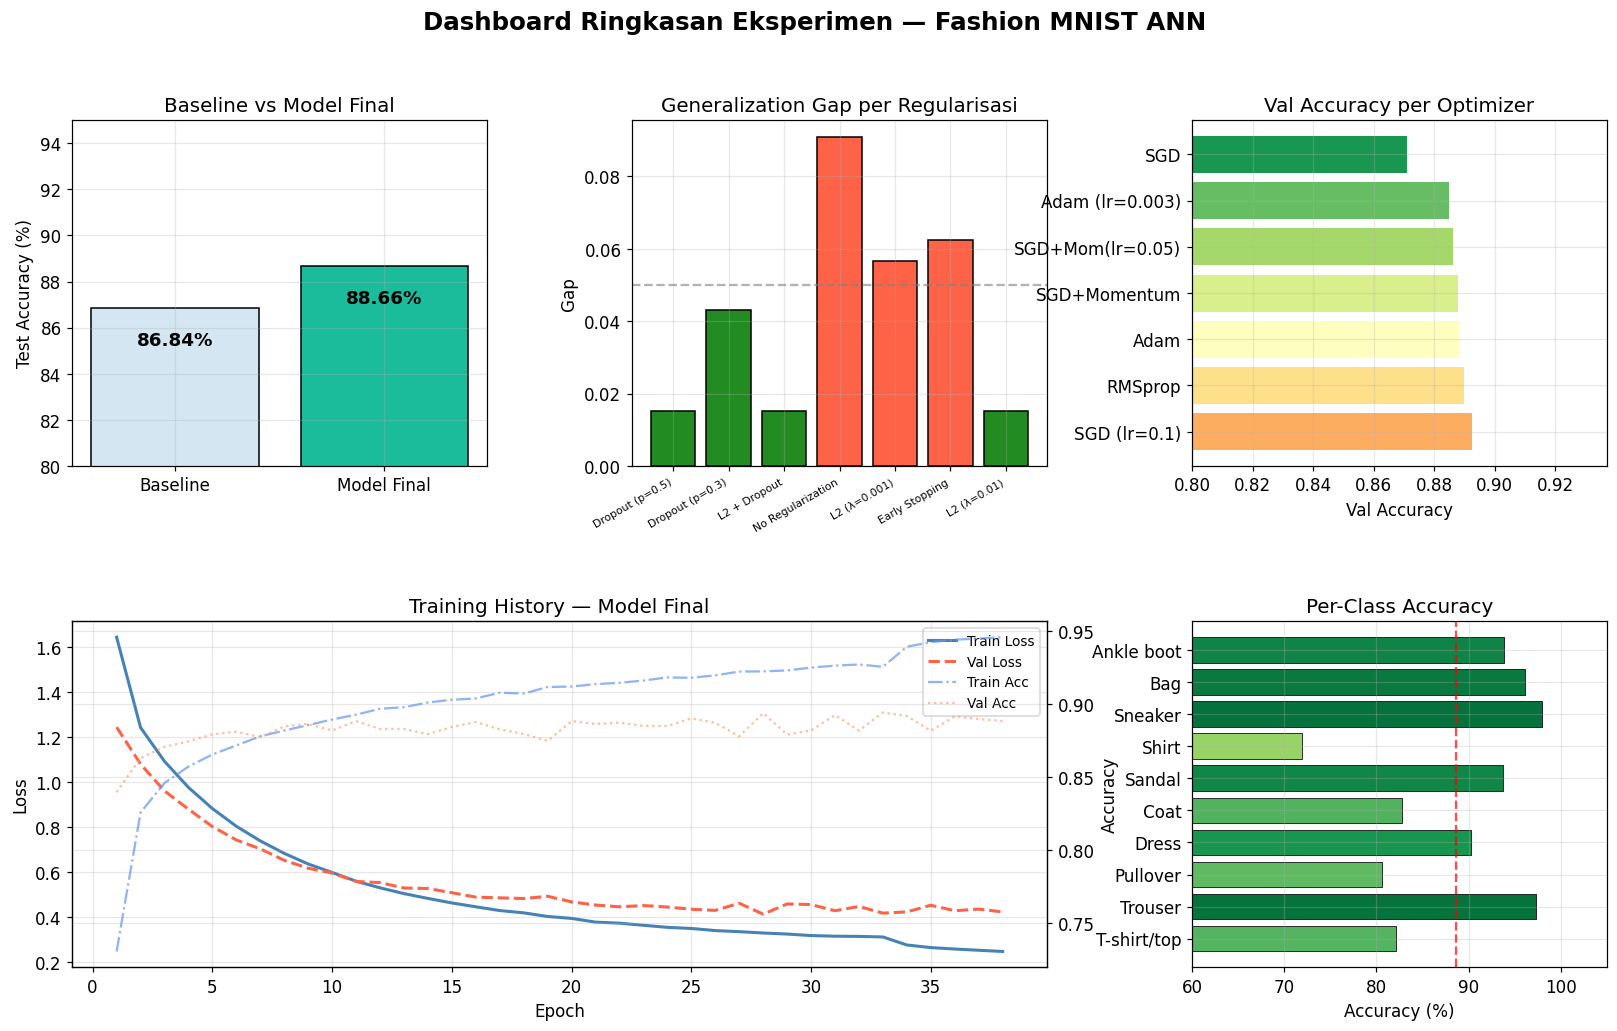


✓ Dashboard tersimpan.

=== HASIL AKHIR ===
Baseline Test Accuracy : 86.84%
Model Final Test Acc   : 88.66%
Improvement            : +1.82%


In [ ]:
# ─── Visualisasi Akhir: Summary Dashboard ───
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Dashboard Ringkasan Eksperimen — Fashion MNIST ANN', fontweight='bold', fontsize=16)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Baseline vs Final Model
ax1 = fig.add_subplot(gs[0, 0])
models_comp = ['Baseline', 'Model Final']
accs_comp   = [baseline_test_acc * 100, test_acc * 100]
colors_comp = ['#d4e6f1', '#1abc9c']
bars1 = ax1.bar(models_comp, accs_comp, color=colors_comp, edgecolor='black')
for bar, acc in zip(bars1, accs_comp):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1,
             f'{acc:.2f}%', ha='center', va='top', fontweight='bold', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)'); ax1.set_title('Baseline vs Model Final')
ax1.set_ylim([80, 95])

# Plot 2: Effect of Regularization on Gap
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(range(len(reg_df)), reg_df['Gap (Overfit)'],
        color=['tomato' if g > 0.05 else 'forestgreen' for g in reg_df['Gap (Overfit)']],
        edgecolor='black')
ax2.set_xticks(range(len(reg_df)))
ax2.set_xticklabels(reg_df['Metode'], rotation=30, ha='right', fontsize=7)
ax2.axhline(0.05, color='gray', linestyle='--', alpha=0.6)
ax2.set_title('Generalization Gap per Regularisasi'); ax2.set_ylabel('Gap')

# Plot 3: Optimizer comparison
ax3 = fig.add_subplot(gs[0, 2])
ax3.barh(opt_df['Optimizer'], opt_df['Val Acc'],
         color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(opt_df))))
ax3.set_xlabel('Val Accuracy'); ax3.set_title('Val Accuracy per Optimizer')
ax3.set_xlim([0.8, None])

# Plot 4: Final model history
ax4 = fig.add_subplot(gs[1, :2])
ep = range(1, len(final_history.history['loss'])+1)
ax4.plot(ep, final_history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
ax4.plot(ep, final_history.history['val_loss'], label='Val Loss', color='tomato',
         linestyle='--', linewidth=2)
ax4_r = ax4.twinx()
ax4_r.plot(ep, final_history.history['accuracy'], label='Train Acc',
           color='cornflowerblue', linestyle='-.', linewidth=1.5, alpha=0.7)
ax4_r.plot(ep, final_history.history['val_accuracy'], label='Val Acc',
           color='lightsalmon', linestyle=':', linewidth=1.5, alpha=0.7)
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Loss'); ax4_r.set_ylabel('Accuracy')
ax4.set_title('Training History — Model Final')
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_r.get_legend_handles_labels()
ax4.legend(lines1+lines2, labels1+labels2, fontsize=9)

# Plot 5: Per-class accuracy final
ax5 = fig.add_subplot(gs[1, 2])
ax5.barh(CLASS_NAMES, per_class_acc * 100,
         color=plt.cm.RdYlGn(per_class_acc), edgecolor='black', linewidth=0.5)
ax5.axvline(test_acc * 100, color='red', linestyle='--', alpha=0.7)
ax5.set_xlabel('Accuracy (%)'); ax5.set_title('Per-Class Accuracy')
ax5.set_xlim([60, 105])

plt.savefig('/content/summary_dashboard.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'\n✓ Dashboard tersimpan.')
print(f'\n=== HASIL AKHIR ===')
print(f'Baseline Test Accuracy : {baseline_test_acc*100:.2f}%')
print(f'Model Final Test Acc   : {test_acc*100:.2f}%')
print(f'Improvement            : +{(test_acc - baseline_test_acc)*100:.2f}%')


In [ ]:
# ─── Kesimpulan Akhir ───
print('=' * 80)
print('KESIMPULAN EKSPERIMEN')
print('=' * 80)
conclusions = """
1. PREPROCESSING
   Normalisasi piksel ke [0,1] sangat penting — tanpanya loss surface menjadi
   elongated dan gradient descent konvergen sangat lambat. Pembagian 85/15 untuk
   train/val memastikan evaluasi hyperparameter yang adil.

2. ARSITEKTUR (Layer & Neuron)
   Arsitektur [512, 256, 128] memberikan kapasitas representasi yang cukup tanpa
   berlebihan. Menambah layer meningkatkan akurasi hingga batas tertentu, setelah
   itu regularisasi menjadi lebih penting.

3. HYPERPARAMETER TUNING (Coarse-to-Fine)
   Pendekatan coarse-to-fine search efektif: search luas dulu untuk
   mengidentifikasi region optimal, kemudian fine search untuk pinpoint LR terbaik.
   LR adalah hyperparameter paling kritis (sesuai prioritas Andrew Ng).

4. REGULARIZATION
   - Dropout efektif mengurangi overfitting dengan memaksa distribusi representasi
   - L2 bekerja dengan penalti pada bobot besar
   - Kombinasi L2 + Dropout memberikan hasil terbaik dalam eksperimen ini
   - Early Stopping mencegah overfitting secara elegan namun memiliki downside:
     coupling antara optimasi dan regularisasi

5. BATCH NORMALIZATION
   BN mempercepat konvergensi dan menstabilkan training. BN memungkinkan LR lebih
   besar karena mengurangi sensitivitas terhadap inisialisasi bobot.

6. WEIGHT INITIALIZATION
   He Initialization dirancang untuk ReLU dan memberikan konvergensi paling cepat.
   Inisialisasi yang buruk (misal std terlalu besar) menyebabkan exploding gradient.

7. OPTIMIZER
   Adam secara konsisten mengungguli SGD dan bahkan SGD+Momentum karena adaptive
   learning rate per parameter dan bias correction. Adam + LR yang tepat adalah
   kombinasi terbaik untuk sebagian besar arsitektur.

8. BATCH SIZE
   Batch size sedang (128) memberikan keseimbangan terbaik antara kecepatan
   komputasi, noise yang cukup untuk regularisasi implisit, dan kualitas gradient.

KONFIGURASI OPTIMAL AKHIR:
   Arsitektur [512, 256, 128] + ReLU + He Init + Adam + BN + L2(0.0005) + Dropout(0.3)
   + Early Stopping → Test Accuracy meningkat signifikan dari baseline.
"""
print(conclusions)

KESIMPULAN EKSPERIMEN

1. PREPROCESSING
   Normalisasi piksel ke [0,1] sangat penting — tanpanya loss surface menjadi
   elongated dan gradient descent konvergen sangat lambat. Pembagian 85/15 untuk
   train/val memastikan evaluasi hyperparameter yang adil.

2. ARSITEKTUR (Layer & Neuron)
   Arsitektur [512, 256, 128] memberikan kapasitas representasi yang cukup tanpa
   berlebihan. Menambah layer meningkatkan akurasi hingga batas tertentu, setelah
   itu regularisasi menjadi lebih penting.

3. HYPERPARAMETER TUNING (Coarse-to-Fine)
   Pendekatan coarse-to-fine search efektif: search luas dulu untuk
   mengidentifikasi region optimal, kemudian fine search untuk pinpoint LR terbaik.
   LR adalah hyperparameter paling kritis (sesuai prioritas Andrew Ng).

4. REGULARIZATION
   - Dropout efektif mengurangi overfitting dengan memaksa distribusi representasi
   - L2 bekerja dengan penalti pada bobot besar
   - Kombinasi L2 + Dropout memberikan hasil terbaik dalam eksperimen ini
   - Early St